<a href="https://colab.research.google.com/github/postechfiap018-ctrl/TECH_CHALLENGE_FASE1/blob/main/EDA_TECHALLENGE_FASE1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tech Challenge Fase 1 — Item 3: Análise Exploratória de Dados (EDA)

**Objetivo:** Entender quais fatores operacionais impactam a satisfação do cliente (NPS)

---



# **0.0 IMPORTS E CONFIGURAÇÕES**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import warnings
import matplotlib.patches as mpatches

warnings.filterwarnings('ignore')

# Estilo visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Paleta de cores para categorias NPS
NPS_PALETTE = {
    'Detrator':   '#E74C3C',
    'Neutro':     '#F39C12',
    'Promotor':   '#2ECC71'
}

# **1.0 Importar base e análisar dados**

In [3]:
# Carregar a base
df = pd.read_csv('/content/data/desafio_nps_fase_1.csv')

#Visualizar base e contar quantidade de linhas e colunas
print(f'Shape: {df.shape[0]} linhas x {df.shape[1]} colunas')
df.head()

Shape: 2500 linhas x 19 colunas


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [ ]:
# Visão geral dos tipos e valores nulos
info_df = df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

In [ ]:
# Estatísticas gerais, contagem total, média,desvio padrão, minimo, máximo e percentis
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
customer_id,2500.0,1250.50,721.83,1.00,625.75,1250.50,1875.25,2500.00
customer_age,2500.0,43.40,14.89,18.00,31.00,43.00,56.00,69.00
customer_tenure_months,2500.0,61.32,34.48,1.00,31.00,62.00,91.00,119.00
order_id,2500.0,51250.50,721.83,50001.00,50625.75,51250.50,51875.25,52500.00
order_value,2500.0,434.26,289.77,7.76,220.24,375.52,577.29,1983.81
items_quantity,2500.0,3.47,1.69,1.00,2.00,3.00,5.00,6.00
discount_value,2500.0,29.75,29.23,0.02,8.88,20.94,40.83,230.33
payment_installments,2500.0,6.00,3.16,1.00,3.00,6.00,9.00,11.00
delivery_time_days,2500.0,8.02,3.77,2.00,5.00,8.00,11.00,14.00
delivery_delay_days,2500.0,2.19,1.45,0.00,1.00,2.00,3.00,8.00


In [ ]:
#Exemplo dos dados da base
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [ ]:
#Distribuição de clientes por região
# => Sem concentração em uma região específica

region_counts = df['customer_region'].value_counts().reset_index()
region_counts.columns = ['Região', 'Quantidade']
region_counts['Percentual (%)'] = (region_counts['Quantidade'] / region_counts['Quantidade'].sum() * 100).round(1)

print('Distribuição de clientes por região:')
display(region_counts)

Distribuição de clientes por região:


,Região,Quantidade,Percentual (%)
0,Sul,521,20.8
1,Sudeste,520,20.8
2,Norte,506,20.2
3,Nordeste,485,19.4
4,Centro-Oeste,468,18.7


---
#**2.0 Tratamento e Engenharia de Features**

In [4]:
# Classificar clientes pela régua padrão de NPS e criar nova uma variável baseada nela
#    Promotores: 9–10 | Neutros: 7–8 | Detratores: 0–6
###########################################

def classificar_nps(score):
    if score >= 9:
        return 'Promotor'
    elif score >= 7:
        return 'Neutro'
    else:
        return 'Detrator'

df['nps_categoria'] = df['nps_score'].apply(classificar_nps)

#Visualização dos números(contagem dos clientes) agrupado pela nova variável e a média do NPS
print(df['nps_categoria'].value_counts())
print(f'\nNPS Score médio: {df["nps_score"].mean():.2f}')

nps_categoria
Detrator    2109
Neutro       281
Promotor     110
Name: count, dtype: int64

NPS Score médio: 4.38


In [5]:
#Visualização do tipo de NPS por região
#Sem concentração de detratores em uma região específica
nps_pivot_region = pd.crosstab(df['customer_region'], df['nps_categoria'])
nps_pivot_region['Total'] = nps_pivot_region.sum(axis=1)

# Cria as colunas de % dividindo cada categoria pelo Total da linha
for col in ['Promotor', 'Neutro', 'Detrator']:
    nps_pivot_region[f'{col} (%)'] = (nps_pivot_region[col] / nps_pivot_region['Total'] * 100).round(1)

# Organiza a ordem das colunas (Quantidade e Percentual)
colunas_ordenadas = [
    'Promotor', 'Promotor (%)',
    'Neutro', 'Neutro (%)',
    'Detrator', 'Detrator (%)',
    'Total'
]
nps_pivot_region = nps_pivot_region[colunas_ordenadas]

print('Tabela Dinâmica de Categorias NPS por Região:')
display(nps_pivot_region)

Tabela Dinâmica de Categorias NPS por Região:


nps_categoria,Promotor,Promotor (%),Neutro,Neutro (%),Detrator,Detrator (%),Total
customer_region,,,,,,,
Centro-Oeste,25,5.3,49,10.5,394,84.2,468
Nordeste,21,4.3,49,10.1,415,85.6,485
Norte,18,3.6,57,11.3,431,85.2,506
Sudeste,23,4.4,62,11.9,435,83.7,520
Sul,23,4.4,64,12.3,434,83.3,521


In [6]:
# Calcular o NPS consolidado da empresa
#     Fórmula: %Promotores - %Detratores
###########################################
total = len(df)
pct_promotores = (df['nps_categoria'] == 'Promotor').sum() / total * 100
pct_detratores = (df['nps_categoria'] == 'Detrator').sum() / total * 100
pct_neutros    = (df['nps_categoria'] == 'Neutro').sum()   / total * 100

nps_empresa = pct_promotores - pct_detratores

print(f'Promotores : {pct_promotores:.1f}%')
print(f'Neutros    : {pct_neutros:.1f}%')
print(f'Detratores : {pct_detratores:.1f}%')
print(f'\n>>> NPS da Empresa: {nps_empresa:.1f}')

Promotores : 4.4%
Neutros    : 11.2%
Detratores : 84.4%

>>> NPS da Empresa: -80.0


In [7]:
#Criação das variáveis de flags binárias(igual a 0(não) ou 1 (sim))

# Flag: houve atraso na entrega?
df['entrega_atrasada'] = (df['delivery_delay_days'] > 0).astype(int)

# Flag: cliente acionou o suporte?
df['acionou_suporte'] = (df['customer_service_contacts'] > 0).astype(int)

print(f'Entregas com atraso : {df["entrega_atrasada"].mean()*100:.1f}% dos pedidos')
print(f'Clientes c/ suporte : {df["acionou_suporte"].mean()*100:.1f}% dos clientes')


Entregas com atraso : 88.9% dos pedidos
Clientes c/ suporte : 77.8% dos clientes


In [8]:
#Segmentação por faixas (agrupamento)


# Faixa etária
bins = [18, 30, 45, 60, 70]
labels = ['18-29', '30-44', '45-59', '60+']
df['faixa_etaria'] = pd.cut(df['customer_age'], bins=bins, labels=labels, right=False)

# faixa de valor do pedido baseado nos quartis da variavél origem(order_value)
df['faixa_ticket'] = pd.qcut(
    df['order_value'],
    q=4,
    labels=['Baixo', 'Médio-baixo', 'Médio-alto', 'Alto']
)

# Faixa de tempo de relacionamento(faixas frequentemente utilizadas no varejo para qualificar os clientes)
bins_tenure = [1, 7, 13, 37, 61, 125]
labels_tenure = ['Até 6 meses', '6 meses a 1 ano', '1 a 3 anos', '3 a 5 anos', 'Mais de 5 anos']
df['faixa_tempo_relacionamento'] = pd.cut(df['customer_tenure_months'],bins=bins_tenure, labels=labels_tenure, right=False)

# Faixa de número de parcelas
bins_parcelas = [1, 2, 4, 7, 15]
labels_parcelas = ['À vista (1x)', 'Curto prazo (2x-3x)', 'Médio prazo (4x-6x)', 'Longo prazo (7x+)']
df['perfil_parcelamento'] = pd.cut(df['payment_installments'], bins=bins_parcelas, labels=labels_parcelas, right=False)

# Faixa de Desconto baseada nos quartis
df['faixa_desconto'] = pd.qcut(
    df['discount_value'],
    q=4,
    labels=['Desconto Baixo', 'Desconto Médio-baixo', 'Desconto Médio-alto', 'Desconto Alto'])

# Faixa de Atraso na Entrega
bins_atraso = [0, 1, 3, 6, 12]
labels_atraso = ['00.Sem Atraso', '01.Atraso Leve (1-2d)', '02.Atraso Moderado (3-5d)', '03.Atraso Crítico (6d+)']
df['faixa_atraso_entrega'] = pd.cut(df['delivery_delay_days'], bins=bins_atraso, labels=labels_atraso, right=False)

# Faixa de Tempo de Resolução (SLA do Suporte, apenas para quem o acionou)
bins_resolucao = [0, 1, 3, 7, 15]
labels_resolucao = ['01.Imediata (D0)', '02.Rápida (1-2d)', '03.Padrão (3-6d)', '04.Longa (7d+)']
faixas_recortadas = pd.cut(df['resolution_time_days'], bins=bins_resolucao, labels=labels_resolucao, right=False)

# Faixa de qtd. de reclamações
bins_complaints = [0, 4, 6, 15]
labels_complaints = ['01.Fricção Baixa (1-3)', '02.Fricção Moderada (4-5)', '04.Fricção Alta (6+)']
faixas_complaints = pd.cut(df['complaints_count'], bins=bins_complaints, labels=labels_complaints, right=False)
df['faixa_reclamacao'] = np.select([df['complaints_count'] == 0],['00.Sem reclamações'],default=faixas_complaints)

df['faixa_tempo_resolucao'] = np.select([df['acionou_suporte'] == 0], ['00.Não acionou'], default=faixas_recortadas)

df[['entrega_atrasada','faixa_atraso_entrega','acionou_suporte','faixa_tempo_resolucao','faixa_reclamacao','faixa_etaria', 'faixa_ticket',
    'faixa_tempo_relacionamento', 'perfil_parcelamento', 'faixa_desconto']].head()

,entrega_atrasada,faixa_atraso_entrega,acionou_suporte,faixa_tempo_resolucao,faixa_reclamacao,faixa_etaria,faixa_ticket,faixa_tempo_relacionamento,perfil_parcelamento,faixa_desconto
0,1,01.Atraso Leve (1-2d),0,00.Não acionou,01.Fricção Baixa (1-3),60+,Baixo,1 a 3 anos,Médio prazo (4x-6x),Desconto Médio-alto
1,1,02.Atraso Moderado (3-5d),0,00.Não acionou,01.Fricção Baixa (1-3),18-29,Médio-alto,Até 6 meses,Longo prazo (7x+),Desconto Médio-baixo
2,1,01.Atraso Leve (1-2d),1,03.Padrão (3-6d),04.Fricção Alta (6+),45-59,Médio-alto,Mais de 5 anos,Médio prazo (4x-6x),Desconto Alto
3,1,01.Atraso Leve (1-2d),1,04.Longa (7d+),02.Fricção Moderada (4-5),45-59,Médio-baixo,Mais de 5 anos,Longo prazo (7x+),Desconto Médio-baixo
4,1,01.Atraso Leve (1-2d),1,01.Imediata (D0),01.Fricção Baixa (1-3),45-59,Médio-baixo,3 a 5 anos,Longo prazo (7x+),Desconto Médio-alto


# **3.0 Análise de Correlação com NPS**

Vamos calcular a correlação da variável `nps_score` com todas as outras variáveis numéricas para identificar quais fatores podem ter maior impacto na satisfação do cliente.

In [9]:
# Calcular a matriz de correlação para as colunas numéricas
correlation_matrix = df.select_dtypes(include=np.number).corr()

# Obter as correlações com 'nps_score'
nps_correlations = correlation_matrix['nps_score'].sort_values(ascending=False)

print('Correlação com NPS Score (do maior para o menor):')
print(nps_correlations)

Correlação com NPS Score (do maior para o menor):
nps_score                    1.000000
repeat_purchase_30d          0.570324
csat_internal_score          0.563952
order_value                  0.036990
delivery_attempts            0.027680
discount_value               0.025104
payment_installments         0.023718
customer_id                  0.015162
order_id                     0.015162
items_quantity               0.011468
delivery_time_days           0.000925
customer_tenure_months      -0.009711
customer_age                -0.009936
freight_value               -0.041087
resolution_time_days        -0.191392
acionou_suporte             -0.247655
entrega_atrasada            -0.348545
customer_service_contacts   -0.350845
complaints_count            -0.496800
delivery_delay_days         -0.597260
Name: nps_score, dtype: float64


### Visualização da Matriz de Correlação com Heatmap

Este mapa de calor mostra a correlação entre todas as variáveis numéricas, com uma escala de cores que varia do vermelho (correlação negativa forte) ao verde (correlação positiva forte).

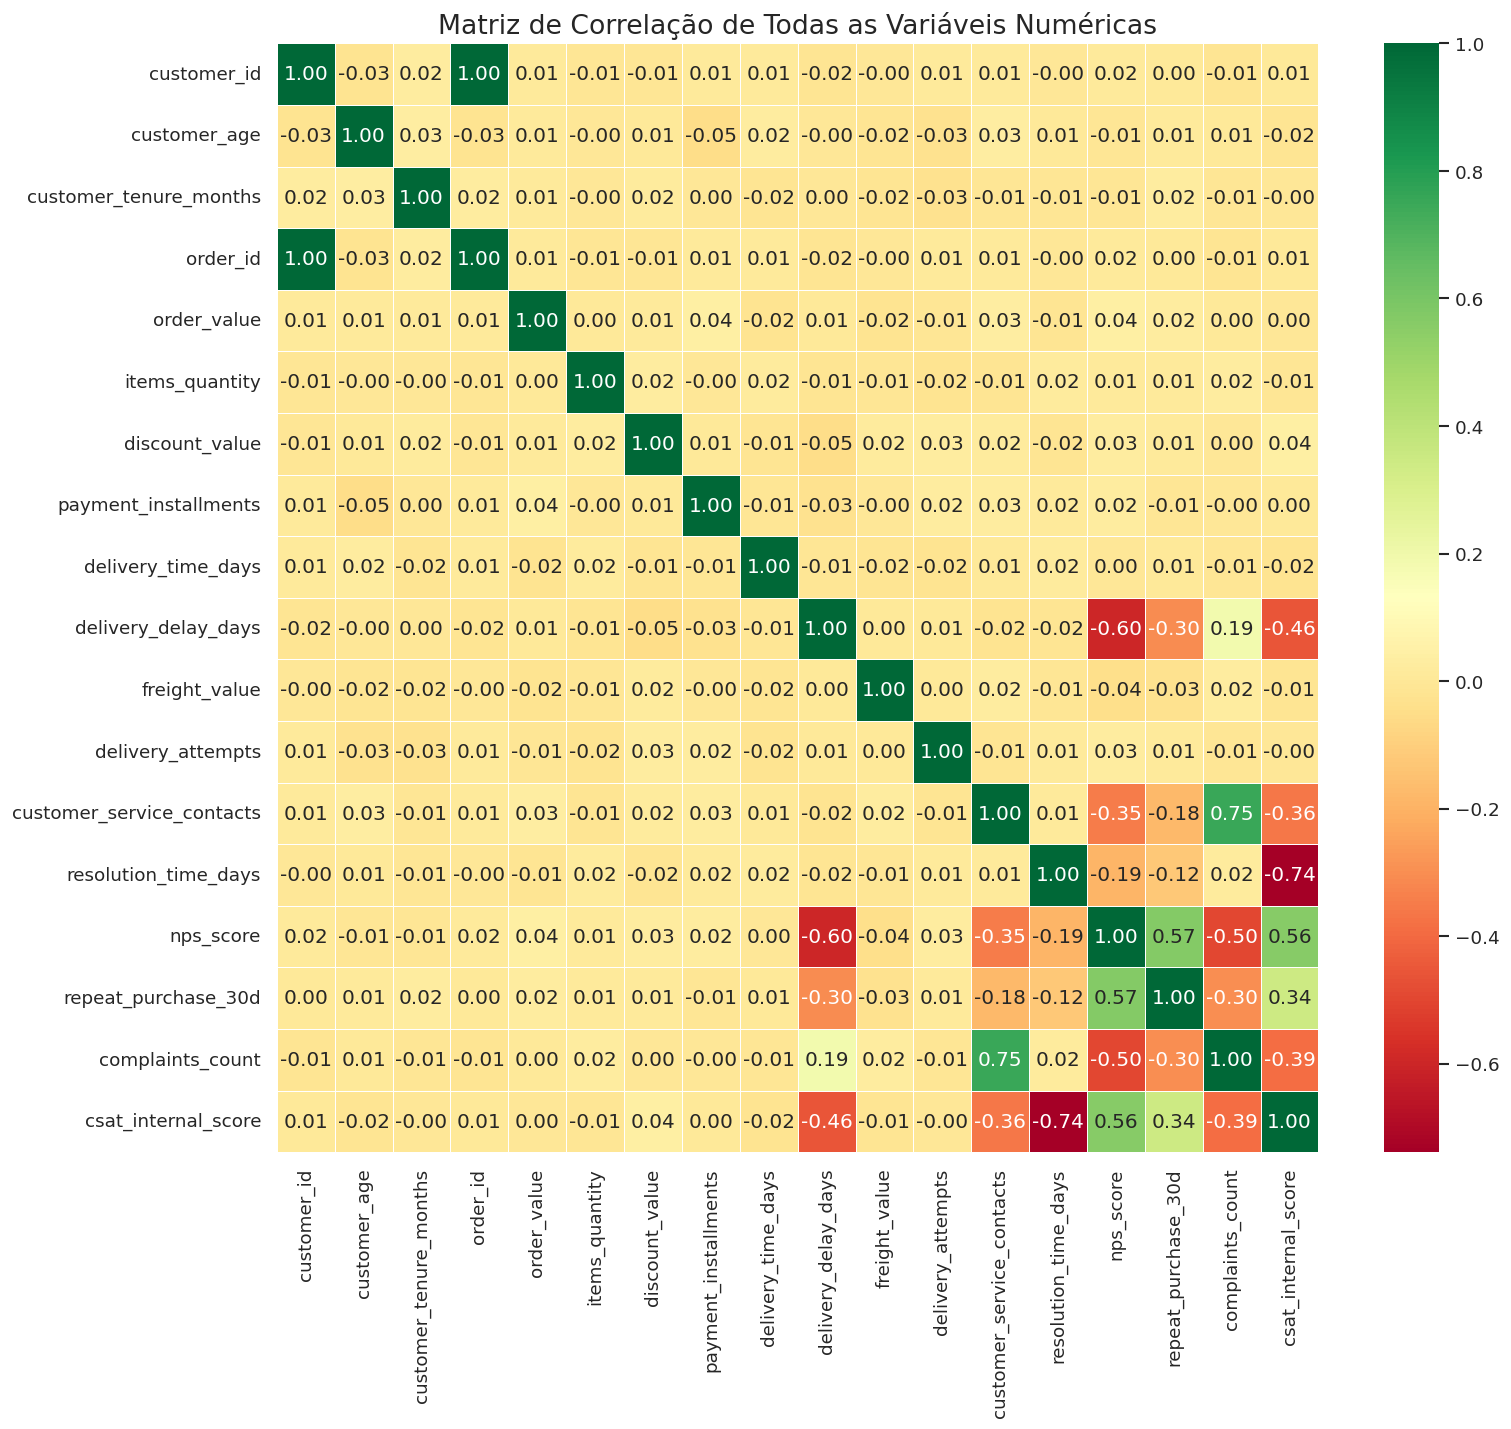

<Figure size 1200x600 with 0 Axes>

In [68]:
#Crição do Heatmap para identificar(em uma visualização gráfica, para facilitar) quais variáveis mais se correlacionam entre si, quais são redundantes
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação de Todas as Variáveis Numéricas', fontsize=16)
plt.show()

#Salvando o gráfico na pasta
plt.tight_layout()
plt.savefig('/content/graficos/heatmap_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

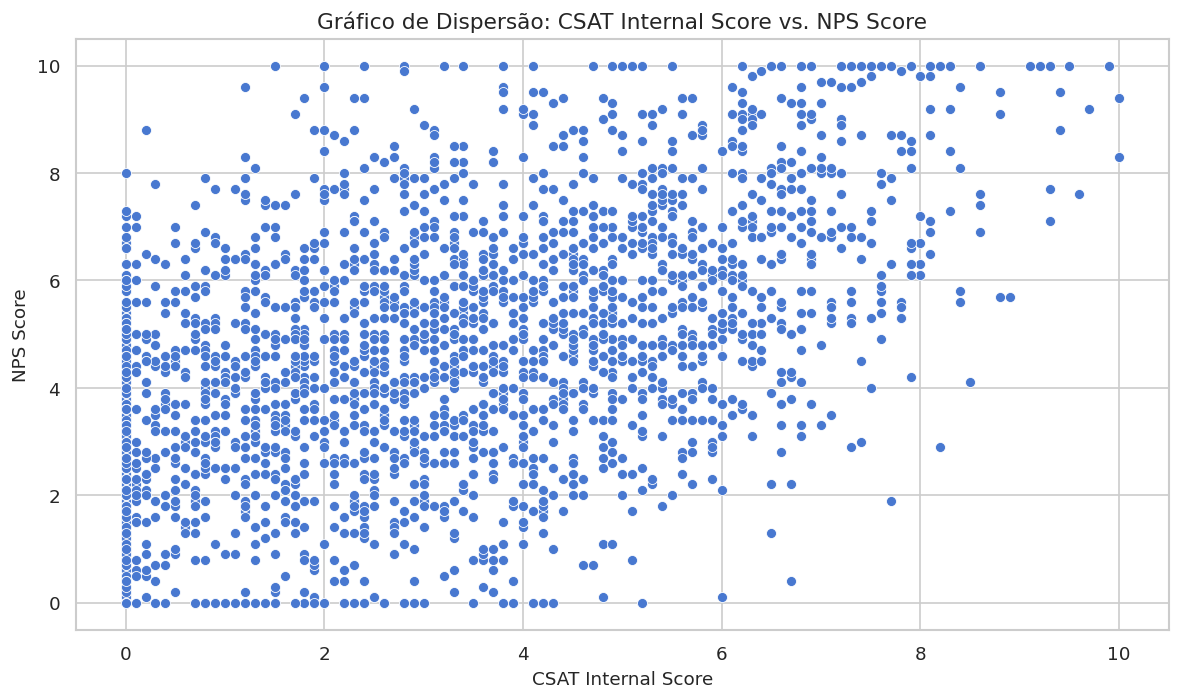

In [39]:
#Gráfico de correlação do score interno com o NPS
#=>Conclusão variáveis não se relacionam, csat/score interno não será usado na análise

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='csat_internal_score', y='nps_score')
plt.title('Gráfico de Dispersão: CSAT Internal Score vs. NPS Score')
plt.xlabel('CSAT Internal Score')
plt.ylabel('NPS Score')
plt.grid(True)

#Salva o PNG do gráfico na pasta
plt.tight_layout()
plt.savefig('/content/graficos/scatterplot_csat_nps.png', dpi=150)
plt.show()

# **4.0 Análise de NPS por Variáveis Categóricas**

Vamos gerar tabelas dinâmicas para entender a distribuição das categorias de NPS (Promotores, Neutros, Detratores) em relação a diferentes faixas e perfis de clientes.

In [ ]:
# Tabela Dinâmica de NPS por Faixa de Atraso na Entrega
nps_faixa_atraso_entrega = pd.crosstab(df['faixa_atraso_entrega'], df['nps_categoria'])
nps_faixa_atraso_entrega['Total'] = nps_faixa_atraso_entrega.sum(axis=1)

#Cria as colunas de % dividindo cada categoria pelo Total da linha
for col in ['Promotor', 'Neutro', 'Detrator']:
    nps_faixa_atraso_entrega[f'{col} (%)'] = (nps_faixa_atraso_entrega[col] / nps_faixa_atraso_entrega['Total'] * 100).round(1)

#Organiza a ordem das colunas (Quantidade e Percentual lado a lado)
colunas_ordenadas = [
    'Promotor', 'Promotor (%)',
    'Neutro', 'Neutro (%)',
    'Detrator', 'Detrator (%)',
    'Total'
]
nps_faixa_atraso_entrega = nps_faixa_atraso_entrega[colunas_ordenadas]

print('Tabela Dinâmica de NPS por Faixa de Atraso na Entrega:')
display(nps_faixa_atraso_entrega)

Tabela Dinâmica de NPS por Faixa de Atraso na Entrega:


nps_categoria,Promotor,Promotor (%),Neutro,Neutro (%),Detrator,Detrator (%),Total
faixa_atraso_entrega,,,,,,,
00.Sem Atraso,50,18.1,84,30.3,143,51.6,277
01.Atraso Leve (1-2d),57,4.5,181,14.4,1023,81.1,1261
02.Atraso Moderado (3-5d),3,0.3,16,1.8,892,97.9,911
03.Atraso Crítico (6d+),0,0.0,0,0.0,51,100.0,51


In [ ]:
# Tabela Dinâmica de NPS por Faixa de Reclamação
nps_faixa_reclamacao = pd.crosstab(df['faixa_reclamacao'], df['nps_categoria'])
nps_faixa_reclamacao['Total'] = nps_faixa_reclamacao.sum(axis=1)

#Cria as colunas de % dividindo cada categoria pelo Total da linha
for col in ['Promotor', 'Neutro', 'Detrator']:
    nps_faixa_reclamacao[f'{col} (%)'] = (nps_faixa_reclamacao[col] / nps_faixa_reclamacao['Total'] * 100).round(1)

#Organiza a ordem das colunas (Quantidade e Percentual lado a lado)
colunas_ordenadas = [
    'Promotor', 'Promotor (%)',
    'Neutro', 'Neutro (%)',
    'Detrator', 'Detrator (%)',
    'Total'
]
nps_faixa_reclamacao = nps_faixa_reclamacao[colunas_ordenadas]

print('Tabela Dinâmica de Categorias NPS por Faixa de Reclamação:')
display(nps_faixa_reclamacao)

Tabela Dinâmica de Categorias NPS por Faixa de Reclamação:


nps_categoria,Promotor,Promotor (%),Neutro,Neutro (%),Detrator,Detrator (%),Total
faixa_reclamacao,,,,,,,
00.Sem reclamações,9,39.1,10,43.5,4,17.4,23
01.Fricção Baixa (1-3),80,8.8,194,21.4,632,69.8,906
02.Fricção Moderada (4-5),20,1.9,65,6.2,959,91.9,1044
04.Fricção Alta (6+),1,0.2,12,2.3,514,97.5,527


In [ ]:
delivery_delay_region = pd.crosstab(df['customer_region'], df['faixa_atraso_entrega'])

# Guarda as categorias originais de atraso antes de calcular o total
colunas_originais = list(delivery_delay_region.columns)

# Adiciona o Total da linha
delivery_delay_region['Total'] = delivery_delay_region.sum(axis=1)

#Cria as colunas de % dinamicamente para cada faixa de atraso
for col in colunas_originais:
    delivery_delay_region[f'{col} (%)'] = (delivery_delay_region[col] / delivery_delay_region['Total'] * 100).round(1)

#Organiza a ordem para que o % fique sempre ao lado da sua quantidade
colunas_ordenadas = []
for col in colunas_originais:
    colunas_ordenadas.extend([col, f'{col} (%)'])
colunas_ordenadas.append('Total')

delivery_delay_region = delivery_delay_region[colunas_ordenadas]

print('Tabela Dinâmica de Faixa de Atraso na Entrega por Região:')
display(delivery_delay_region)

Tabela Dinâmica de Faixa de Atraso na Entrega por Região:


faixa_atraso_entrega,00.Sem Atraso,00.Sem Atraso (%),01.Atraso Leve (1-2d),01.Atraso Leve (1-2d) (%),02.Atraso Moderado (3-5d),02.Atraso Moderado (3-5d) (%),03.Atraso Crítico (6d+),03.Atraso Crítico (6d+) (%),Total
customer_region,,,,,,,,,
Centro-Oeste,58,12.4,223,47.6,177,37.8,10,2.1,468
Nordeste,48,9.9,249,51.3,181,37.3,7,1.4,485
Norte,61,12.1,254,50.2,180,35.6,11,2.2,506
Sudeste,47,9.0,272,52.3,189,36.3,12,2.3,520
Sul,63,12.1,263,50.5,184,35.3,11,2.1,521


In [ ]:
nps_faixa_etaria = pd.crosstab(df['faixa_etaria'], df['nps_categoria'])
nps_faixa_etaria['Total'] = nps_faixa_etaria.sum(axis=1)

#Cria as colunas de % dividindo cada categoria pelo Total da linha
for col in ['Promotor', 'Neutro', 'Detrator']:
    nps_faixa_etaria[f'{col} (%)'] = (nps_faixa_etaria[col] / nps_faixa_etaria['Total'] * 100).round(1)

#Organiza a ordem das colunas (Quantidade e Percentual lado a lado)
colunas_ordenadas = [
    'Promotor', 'Promotor (%)',
    'Neutro', 'Neutro (%)',
    'Detrator', 'Detrator (%)',
    'Total'
]
nps_faixa_etaria = nps_faixa_etaria[colunas_ordenadas]

print('Tabela Dinâmica de Categorias NPS por Faixa Etária:')
display(nps_faixa_etaria)

Tabela Dinâmica de Categorias NPS por Faixa Etária:


nps_categoria,Promotor,Promotor (%),Neutro,Neutro (%),Detrator,Detrator (%),Total
faixa_etaria,,,,,,,
18-29,24,4.3,73,13.0,464,82.7,561
30-44,35,4.6,73,9.7,645,85.7,753
45-59,28,3.9,80,11.1,615,85.1,723
60+,23,5.0,55,11.9,385,83.2,463


In [ ]:
nps_faixa_ticket = pd.crosstab(df['faixa_ticket'], df['nps_categoria'])
nps_faixa_ticket['Total'] = nps_faixa_ticket.sum(axis=1)

#Cria as colunas de % dividindo cada categoria pelo Total da linha
for col in ['Promotor', 'Neutro', 'Detrator']:
    nps_faixa_ticket[f'{col} (%)'] = (nps_faixa_ticket[col] / nps_faixa_ticket['Total'] * 100).round(1)

#Organiza a ordem das colunas (Quantidade e Percentual lado a lado)
colunas_ordenadas = [
    'Promotor', 'Promotor (%)',
    'Neutro', 'Neutro (%)',
    'Detrator', 'Detrator (%)',
    'Total'
]
nps_faixa_ticket = nps_faixa_ticket[colunas_ordenadas]

print('\nTabela Dinâmica de Categorias NPS por Faixa de Ticket:')
display(nps_faixa_ticket)


Tabela Dinâmica de Categorias NPS por Faixa de Ticket:


nps_categoria,Promotor,Promotor (%),Neutro,Neutro (%),Detrator,Detrator (%),Total
faixa_ticket,,,,,,,
Baixo,19,3.0,65,10.4,541,86.6,625
Médio-baixo,31,5.0,72,11.5,522,83.5,625
Médio-alto,26,4.2,68,10.9,531,85.0,625
Alto,34,5.4,76,12.2,515,82.4,625


In [ ]:
#Tabela Dinâmica de Categorias NPS por Faixa de Tempo de Relacionamento

#Define as variáveis a serem agrupadas e as a serem sumarizadas
nps_faixa_tempo_relacionamento = pd.crosstab(df['faixa_tempo_relacionamento'], df['nps_categoria'])
nps_faixa_tempo_relacionamento['Total'] = nps_faixa_tempo_relacionamento.sum(axis=1)

# Cria as colunas de % dividindo cada categoria pelo Total da linha
for col in ['Promotor', 'Neutro', 'Detrator']:
    nps_faixa_tempo_relacionamento[f'{col} (%)'] = (nps_faixa_tempo_relacionamento[col] / nps_faixa_tempo_relacionamento['Total'] * 100).round(1)

# Organiza a ordem das colunas (Quantidade e Percentual lado a lado)
colunas_ordenadas = [
    'Promotor', 'Promotor (%)',
    'Neutro', 'Neutro (%)',
    'Detrator', 'Detrator (%)',
    'Total'
]
nps_faixa_tempo_relacionamento = nps_faixa_tempo_relacionamento[colunas_ordenadas]

print('\nTabela Dinâmica de Categorias NPS por Faixa de Tempo de Relacionamento:')
display(nps_faixa_tempo_relacionamento)


Tabela Dinâmica de Categorias NPS por Faixa de Tempo de Relacionamento:


nps_categoria,Promotor,Promotor (%),Neutro,Neutro (%),Detrator,Detrator (%),Total
faixa_tempo_relacionamento,,,,,,,
Até 6 meses,3,2.5,15,12.3,104,85.2,122
6 meses a 1 ano,5,4.2,10,8.3,105,87.5,120
1 a 3 anos,24,4.9,60,12.2,406,82.9,490
3 a 5 anos,14,2.9,52,10.9,412,86.2,478
Mais de 5 anos,64,5.0,144,11.2,1082,83.9,1290


In [ ]:
# Tabela Dinâmica de NPS por Perfil de Parcelamento
nps_perfil_parcelamento = pd.crosstab(df['perfil_parcelamento'], df['nps_categoria'])
nps_perfil_parcelamento['Total'] = nps_perfil_parcelamento.sum(axis=1)

# Cria as colunas de % dividindo cada categoria pelo Total da linha
for col in ['Promotor', 'Neutro', 'Detrator']:
    nps_perfil_parcelamento[f'{col} (%)'] = (nps_perfil_parcelamento[col] / nps_perfil_parcelamento['Total'] * 100).round(1)

# Organiza a ordem das colunas (Quantidade e Percentual lado a lado)
colunas_ordenadas = [
    'Promotor', 'Promotor (%)',
    'Neutro', 'Neutro (%)',
    'Detrator', 'Detrator (%)',
    'Total'
]
nps_perfil_parcelamento = nps_perfil_parcelamento[colunas_ordenadas]

print('\nTabela Dinâmica de Categorias NPS por Perfil de Parcelamento:')
display(nps_perfil_parcelamento)


Tabela Dinâmica de Categorias NPS por Perfil de Parcelamento:


nps_categoria,Promotor,Promotor (%),Neutro,Neutro (%),Detrator,Detrator (%),Total
perfil_parcelamento,,,,,,,
À vista (1x),10,4.9,23,11.2,173,84.0,206
Curto prazo (2x-3x),19,3.9,47,9.6,423,86.5,489
Médio prazo (4x-6x),35,5.2,76,11.2,565,83.6,676
Longo prazo (7x+),46,4.1,135,12.0,948,84.0,1129


In [ ]:
# Tabela Dinâmica de NPS por Faixa de Desconto
nps_faixa_desconto = pd.crosstab(df['faixa_desconto'], df['nps_categoria'])
nps_faixa_desconto['Total'] = nps_faixa_desconto.sum(axis=1)

# Cria as colunas de % dividindo cada categoria pelo Total da linha
for col in ['Promotor', 'Neutro', 'Detrator']:
    nps_faixa_desconto[f'{col} (%)'] = (nps_faixa_desconto[col] / nps_faixa_desconto['Total'] * 100).round(1)

# Organiza a ordem das colunas (Quantidade e Percentual lado a lado)
colunas_ordenadas = [
    'Promotor', 'Promotor (%)',
    'Neutro', 'Neutro (%)',
    'Detrator', 'Detrator (%)',
    'Total'
]
nps_faixa_desconto = nps_faixa_desconto[colunas_ordenadas]

print('Tabela Dinâmica de Categorias NPS por Faixa de Desconto:')
display(nps_faixa_desconto)

Tabela Dinâmica de Categorias NPS por Faixa de Desconto:


nps_categoria,Promotor,Promotor (%),Neutro,Neutro (%),Detrator,Detrator (%),Total
faixa_desconto,,,,,,,
Desconto Baixo,30,4.8,63,10.1,532,85.1,625
Desconto Médio-baixo,14,2.2,69,11.0,542,86.7,625
Desconto Médio-alto,31,5.0,81,13.0,513,82.1,625
Desconto Alto,35,5.6,68,10.9,522,83.5,625


## 4.1 Análise de Tentativas de Entrega por Região

Vamos analisar a distribuição das tentativas de entrega para cada região, para identificar possíveis padrões ou problemas regionais.

In [ ]:
delivery_attempts_region = pd.crosstab(df['customer_region'], df['delivery_attempts'])

# Guarda as categorias originais de tentativas de entrega antes de calcular o total
colunas_originais = sorted(df['delivery_attempts'].unique().tolist())

# Adiciona o Total da linha
delivery_attempts_region['Total'] = delivery_attempts_region.sum(axis=1)

# Cria as colunas de % dinamicamente para cada faixa de atraso
for col in colunas_originais:
    delivery_attempts_region[f'{col} (%)'] = (delivery_attempts_region[col] / delivery_attempts_region['Total'] * 100).round(1)

# Organiza a ordem para que o % fique sempre ao lado da sua quantidade
colunas_ordenadas = []
for col in colunas_originais:
    colunas_ordenadas.extend([col, f'{col} (%)'])
colunas_ordenadas.append('Total')

delivery_attempts_region = delivery_attempts_region[colunas_ordenadas]

print('Tabela Dinâmica de Tentativas de Entrega por Região:')
display(delivery_attempts_region)

Tabela Dinâmica de Tentativas de Entrega por Região:


delivery_attempts,1,1 (%),2,2 (%),3,3 (%),Total
customer_region,,,,,,,
Centro-Oeste,151,32.3,166,35.5,151,32.3,468
Nordeste,157,32.4,164,33.8,164,33.8,485
Norte,173,34.2,171,33.8,162,32.0,506
Sudeste,164,31.5,173,33.3,183,35.2,520
Sul,179,34.4,164,31.5,178,34.2,521


## 4.2 Análise de Vendas por Região e Faixa Etária

Para entender a contribuição de cada grupo demográfico e geográfico, vamos visualizar o valor total dos pedidos e a quantidade total de itens comprados por região e faixa etária.

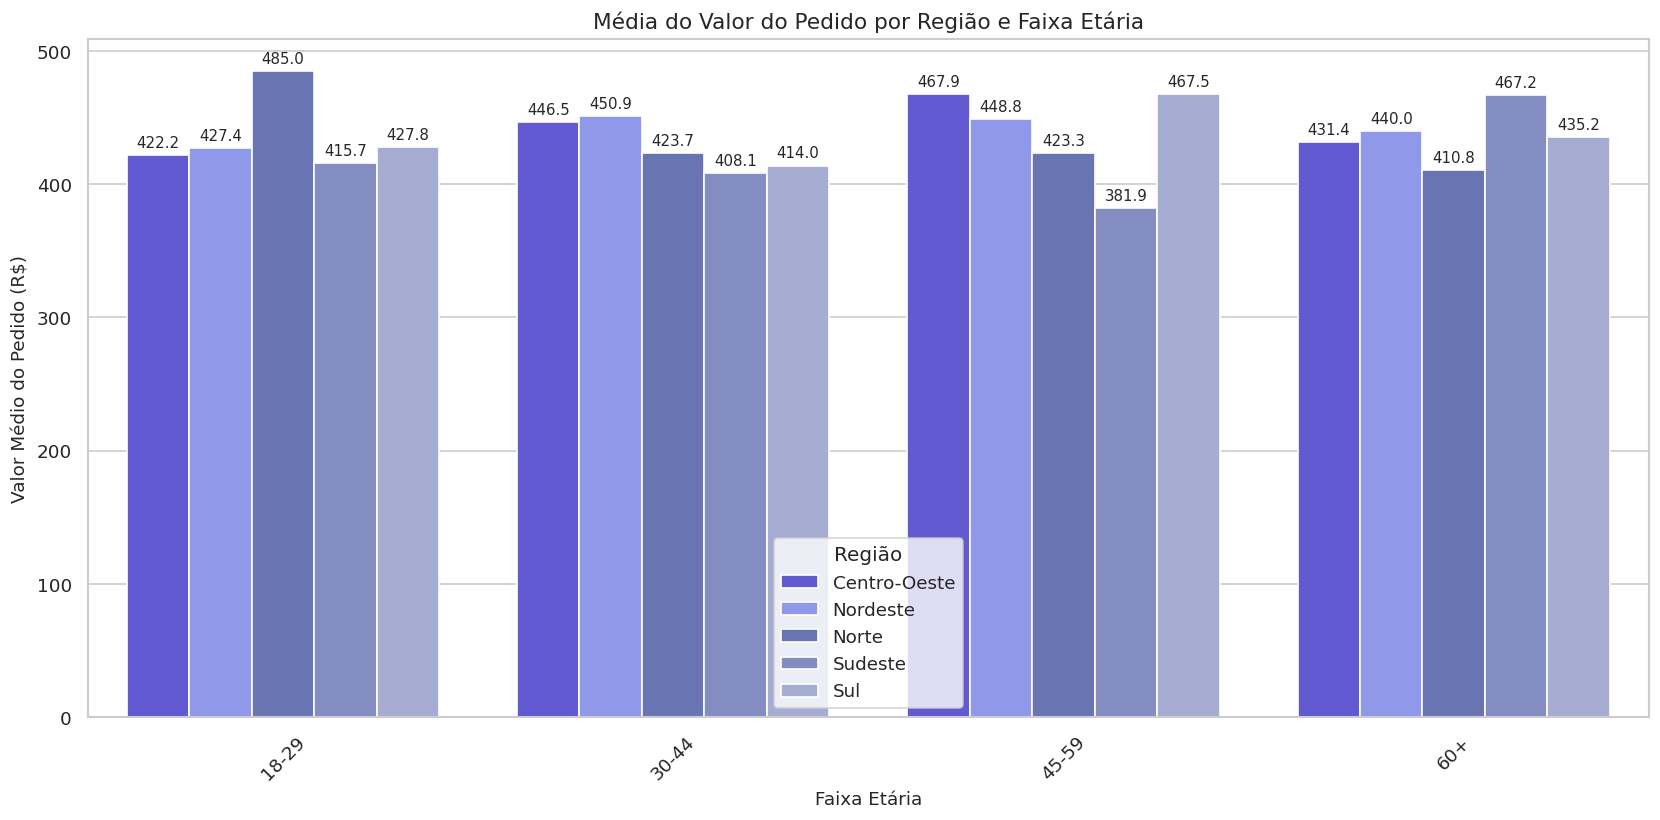

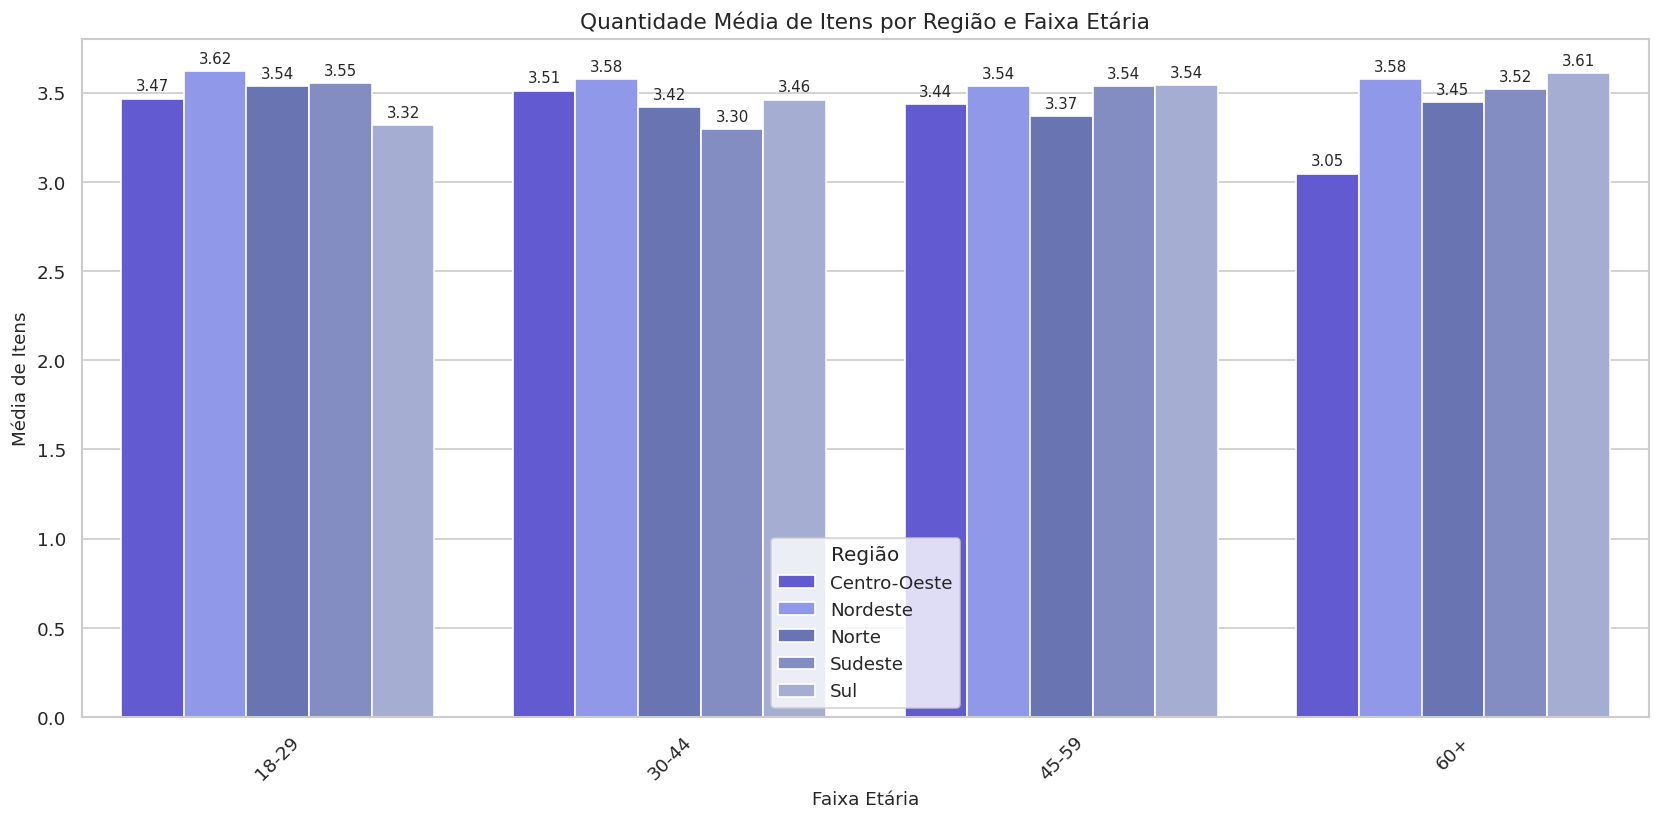

In [9]:
df_agg_region_age = df.groupby(['customer_region', 'faixa_etaria']).agg(
    avg_order_value=('order_value', 'mean'),
    avg_items_quantity=('items_quantity', 'mean')
).reset_index()

custom_region_palette = ['#4f46e5', '#818cf8', '#5c6bc0', '#7986cb', '#9fa8da']

plt.figure(figsize=(14, 7))
ax1 = sns.barplot(data=df_agg_region_age, x='faixa_etaria', y='avg_order_value', hue='customer_region', palette=custom_region_palette)
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f', padding=3, fontsize=9)
plt.title('Média do Valor do Pedido por Região e Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Valor Médio do Pedido (R$)')
plt.xticks(rotation=45)
plt.legend(title='Região')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 7))
ax2 = sns.barplot(data=df_agg_region_age, x='faixa_etaria', y='avg_items_quantity', hue='customer_region', palette=custom_region_palette)
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.2f', padding=3, fontsize=9)
plt.title('Quantidade Média de Itens por Região e Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Média de Itens')
plt.xticks(rotation=45)
plt.legend(title='Região')
plt.tight_layout()
plt.show()

In [42]:
# Tabela Dinâmica de NPS por Compra nos Últimos 30 Dias
nps_repeat_purchase = pd.crosstab(df['repeat_purchase_30d'], df['nps_categoria'])
nps_repeat_purchase['Total'] = nps_repeat_purchase.sum(axis=1)
nps_repeat_purchase = nps_repeat_purchase[['Promotor', 'Neutro', 'Detrator', 'Total']]
print('Tabela Dinâmica de Categorias NPS por Compra nos Últimos 30 Dias:')
display(nps_repeat_purchase)

Tabela Dinâmica de Categorias NPS por Compra nos Últimos 30 Dias:


nps_categoria,Promotor,Neutro,Detrator,Total
repeat_purchase_30d,,,,
0,0,173,2109,2282
1,110,108,0,218


In [43]:
# Tabela Dinâmica de Contatos com o Serviço de Atendimento ao Cliente por Número de Reclamações
customer_service_complaints_pivot = pd.crosstab(df['customer_service_contacts'], df['complaints_count'])

print('Tabela Dinâmica de Contatos com o Serviço de Atendimento ao Cliente por Número de Reclamações:')
display(customer_service_complaints_pivot)

Tabela Dinâmica de Contatos com o Serviço de Atendimento ao Cliente por Número de Reclamações:


complaints_count,0,1,2,3,4,5,6,7,8,9,10,11
customer_service_contacts,,,,,,,,,,,,
0,23,91,182,136,92,22,7,0,1,0,0,0
1,0,31,82,304,247,110,27,13,2,0,0,0
2,0,0,13,63,236,204,80,36,8,0,0,0
3,0,0,0,4,24,106,102,61,15,2,0,0
4,0,0,0,0,1,2,49,41,24,10,5,0
5,0,0,0,0,0,0,1,18,10,3,1,1
6,0,0,0,0,0,0,0,0,3,0,4,0
7,0,0,0,0,0,0,0,0,0,1,1,1


In [44]:
customer_service_complaints_pivot = pd.crosstab(df['delivery_delay_days'], df['complaints_count'])
customer_service_complaints_pivot['Total'] = customer_service_complaints_pivot.sum(axis=1)

print('Tabela Dinâmica: Dias de Atraso por Quantidade de Reclamações:')
display(customer_service_complaints_pivot)

Tabela Dinâmica: Dias de Atraso por Quantidade de Reclamações:


complaints_count,0,1,2,3,4,5,6,7,8,9,10,11,Total
delivery_delay_days,,,,,,,,,,,,,
0,23,54,45,56,45,24,16,6,4,3,1,0,277
1,0,31,87,131,123,108,66,43,17,5,3,1,615
2,0,23,70,117,181,124,69,46,11,3,2,0,646
3,0,9,48,113,137,103,57,37,16,1,3,1,525
4,0,4,13,55,75,51,39,24,8,1,0,0,270
5,0,1,11,25,26,20,14,12,4,2,1,0,116
6,0,0,1,7,7,11,3,1,2,1,1,0,34
7,0,0,2,3,4,2,2,0,1,0,0,0,14
8,0,0,0,0,2,1,0,0,0,0,0,0,3


## **5.1 CORRELAÇÃO COM O NPS**

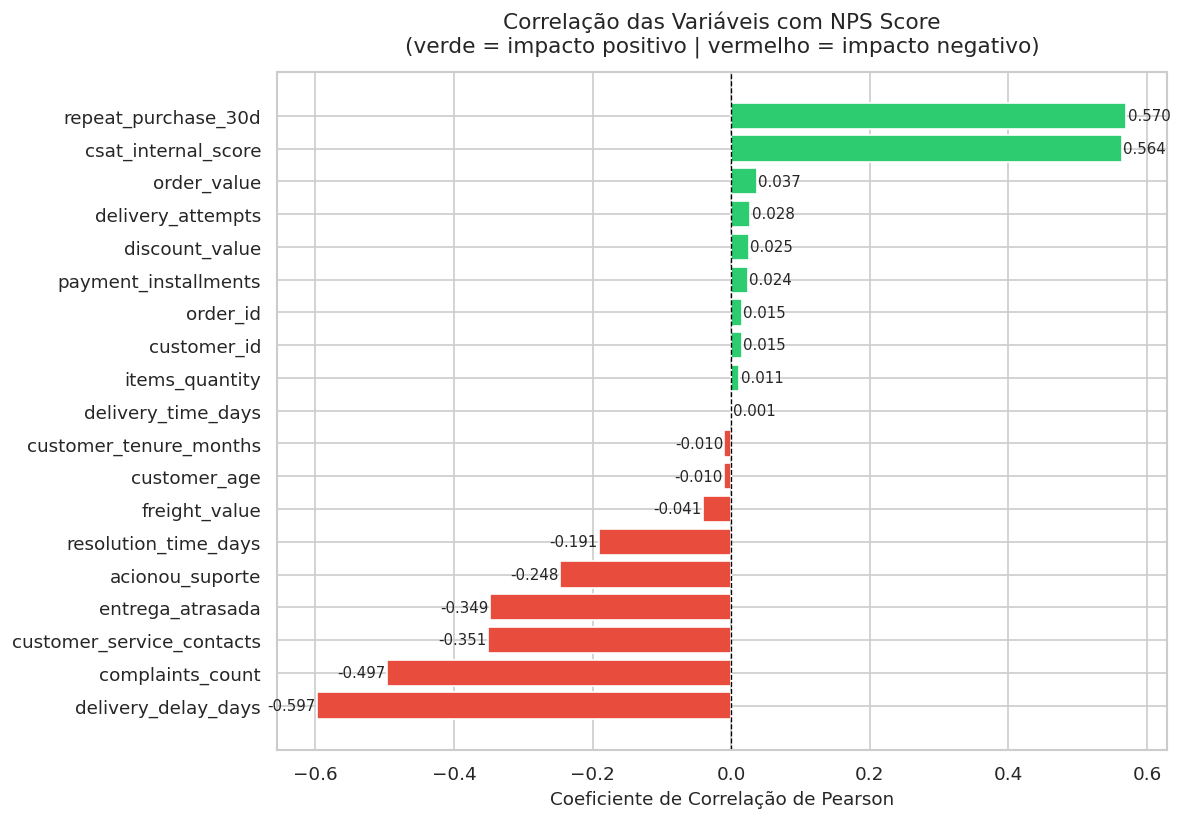


▶ Análise: Os fatores com maior impacto NEGATIVO no NPS são:
   • delivery_delay_days  – atraso na entrega
   • complaints_count     – número de reclamações
   • customer_service_contacts – contatos com suporte

   Os fatores com maior impacto POSITIVO são:
   • repeat_purchase_30d   – recompra recente



In [48]:
# ── 7.1 Ranking de correlação com NPS ──────────────────────────────────────
corr = df.select_dtypes(include='number').corr()['nps_score'].drop('nps_score').sort_values()

cores = ['#E74C3C' if v < 0 else '#2ECC71' for v in corr]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(corr.index, corr.values, color=cores)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Correlação das Variáveis com NPS Score\n(verde = impacto positivo | vermelho = impacto negativo)', fontsize=13, pad=12)
ax.set_xlabel('Coeficiente de Correlação de Pearson')

for bar, val in zip(bars, corr.values):
    ax.text(val + (0.002 if val >= 0 else -0.002),
            bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('/content/graficos/ranking_correlacao_nps.png', dpi=150, bbox_inches='tight')
plt.show()
print("""
▶ Análise: Os fatores com maior impacto NEGATIVO no NPS são:
   • delivery_delay_days  – atraso na entrega
   • complaints_count     – número de reclamações
   • customer_service_contacts – contatos com suporte

   Os fatores com maior impacto POSITIVO são:
   • repeat_purchase_30d   – recompra recente
""")

##**5.2 O que gera mais detradores**

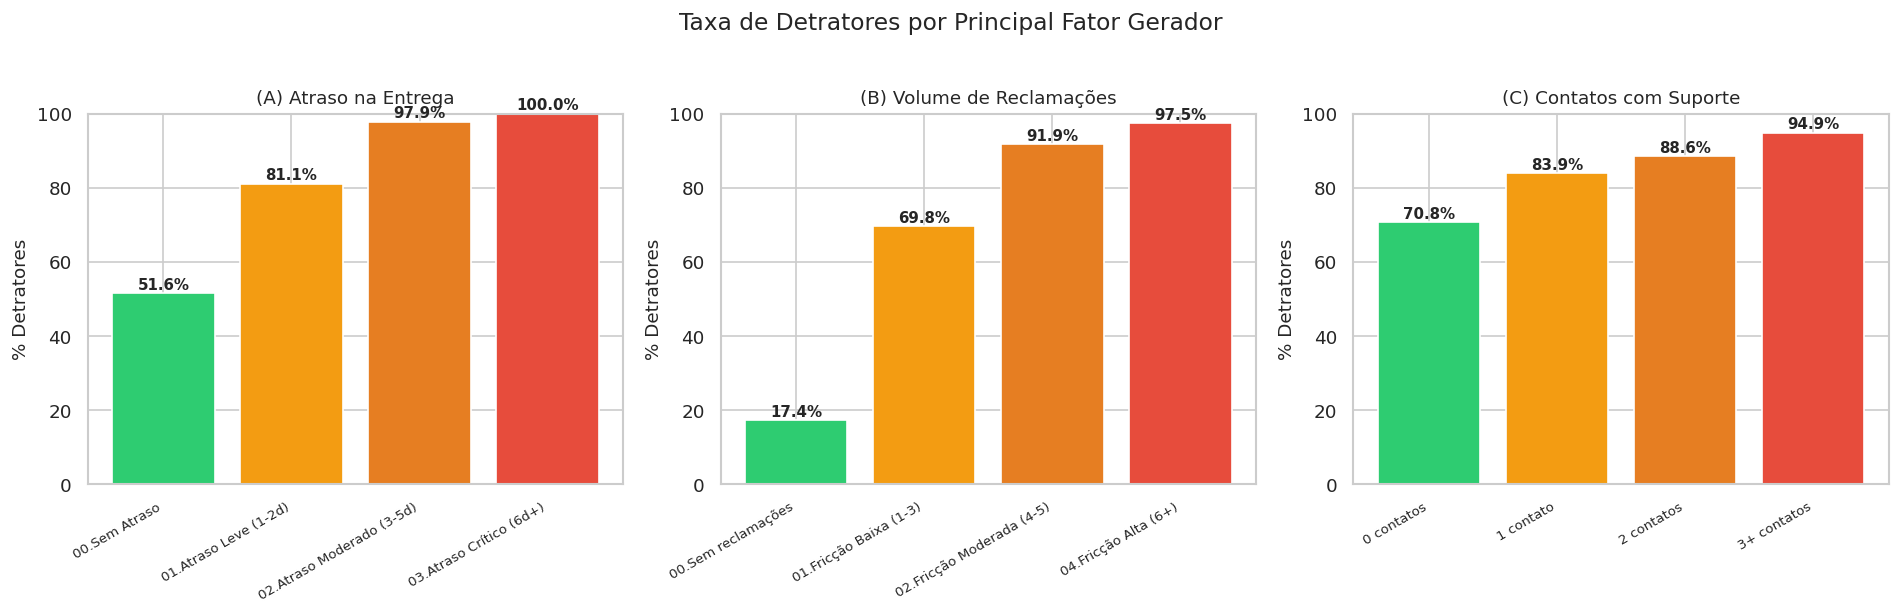


▶ Análise: Os três maiores geradores de detratores são:
   1. Atraso na entrega (a partir de 1 dia): taxa de detratores dispara
   2. Quantidade de reclamações (Fricção Alta 6+): concentração expressiva de detratores
   3. Contatos com suporte (3+): sinal de problema não resolvido



In [49]:
# Taxa de detratores pelas principais variáveis impactantes para o NPS
# Para cada faixa, calculamos: % de clientes que são Detratores (NPS 0-6)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Taxa de Detratores por Principal Fator Gerador', fontsize=14, y=1.02)

# (A) Atraso na entrega
taxa_atraso = (df.groupby('faixa_atraso_entrega', observed=True)['nps_categoria']
               .apply(lambda x: (x == 'Detrator').mean() * 100).reset_index())
taxa_atraso.columns = ['faixa', 'pct_detrator']
taxa_atraso = taxa_atraso.sort_values('faixa')

#Cria gráfico de atraso
ax = axes[0]
bars = ax.bar(range(len(taxa_atraso)), taxa_atraso['pct_detrator'],
              color=['#2ECC71','#F39C12','#E67E22','#E74C3C'])
ax.set_xticks(range(len(taxa_atraso)))
ax.set_xticklabels(taxa_atraso['faixa'], rotation=30, ha='right', fontsize=8)
ax.set_title('(A) Atraso na Entrega', fontsize=11)
ax.set_ylabel('% Detratores')
ax.set_ylim(0, 100)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
            f'{b.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')

# (B) Volume de reclamações
taxa_reclam = (df.groupby('faixa_reclamacao', observed=True)['nps_categoria']
               .apply(lambda x: (x == 'Detrator').mean() * 100).reset_index())
taxa_reclam.columns = ['faixa', 'pct_detrator']
taxa_reclam = taxa_reclam.sort_values('faixa')

ax = axes[1]
bars = ax.bar(range(len(taxa_reclam)), taxa_reclam['pct_detrator'],
              color=['#2ECC71','#F39C12','#E67E22','#E74C3C'])
ax.set_xticks(range(len(taxa_reclam)))
ax.set_xticklabels(taxa_reclam['faixa'], rotation=30, ha='right', fontsize=8)
ax.set_title('(B) Volume de Reclamações', fontsize=11)
ax.set_ylabel('% Detratores')
ax.set_ylim(0, 100)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
            f'{b.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')

# (C) Contatos com suporte (0, 1, 2, 3+)
df['faixa_suporte'] = df['customer_service_contacts'].clip(upper=3).map(
    {0:'0 contatos', 1:'1 contato', 2:'2 contatos', 3:'3+ contatos'})
taxa_suporte = (df.groupby('faixa_suporte', observed=True)['nps_categoria']
                .apply(lambda x: (x == 'Detrator').mean() * 100).reset_index())
taxa_suporte.columns = ['faixa','pct_detrator']
order = ['0 contatos','1 contato','2 contatos','3+ contatos']
taxa_suporte = taxa_suporte.set_index('faixa').reindex(order).reset_index()

ax = axes[2]
bars = ax.bar(range(len(taxa_suporte)), taxa_suporte['pct_detrator'],
              color=['#2ECC71','#F39C12','#E67E22','#E74C3C'])
ax.set_xticks(range(len(taxa_suporte)))
ax.set_xticklabels(taxa_suporte['faixa'], rotation=30, ha='right', fontsize=8)
ax.set_title('(C) Contatos com Suporte', fontsize=11)
ax.set_ylabel('% Detratores')
ax.set_ylim(0, 100)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
            f'{b.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/graficos/taxa_detratores_por_fator.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
▶ Análise: Os três maiores geradores de detratores são:
   1. Atraso na entrega (a partir de 1 dia): taxa de detratores dispara
   2. Quantidade de reclamações (Fricção Alta 6+): concentração expressiva de detratores
   3. Contatos com suporte (3+): sinal de problema não resolvido
""")


In [50]:
#Comparação estatística de atraso vs. sem atraso (teste Mann-Whitney U)
#Avalia se dois grupos(atraso ou não) têm distribuições de NPS diferentes.

g0 = df[df['entrega_atrasada'] == 0]['nps_score']
g1 = df[df['entrega_atrasada'] == 1]['nps_score']
stat, p_valor = stats.mannwhitneyu(g0, g1, alternative='greater')

print(f'NPS médio -- Sem atraso : {g0.mean():.2f}  (n={len(g0)})')
print(f'NPS médio -- Com atraso : {g1.mean():.2f}  (n={len(g1)})')
print(f'\nMann-Whitney U: estatística = {stat:.0f}, p-valor = {p_valor:.4f}')
if p_valor < 0.05:
    print('Diferença significativa (p < 0.05).')
    print('Clientes com entrega no prazo têm NPS significativamente mais alto.')
else:
    print('Diferença NÃO é significativa (p >= 0.05).')


NPS médio -- Sem atraso : 6.86  (n=277)
NPS médio -- Com atraso : 4.07  (n=2223)

Mann-Whitney U: estatística = 497578, p-valor = 0.0000
Diferença significativa (p < 0.05).
Clientes com entrega no prazo têm NPS significativamente mais alto.


##**5.3 PONTO DE RUPTURA**

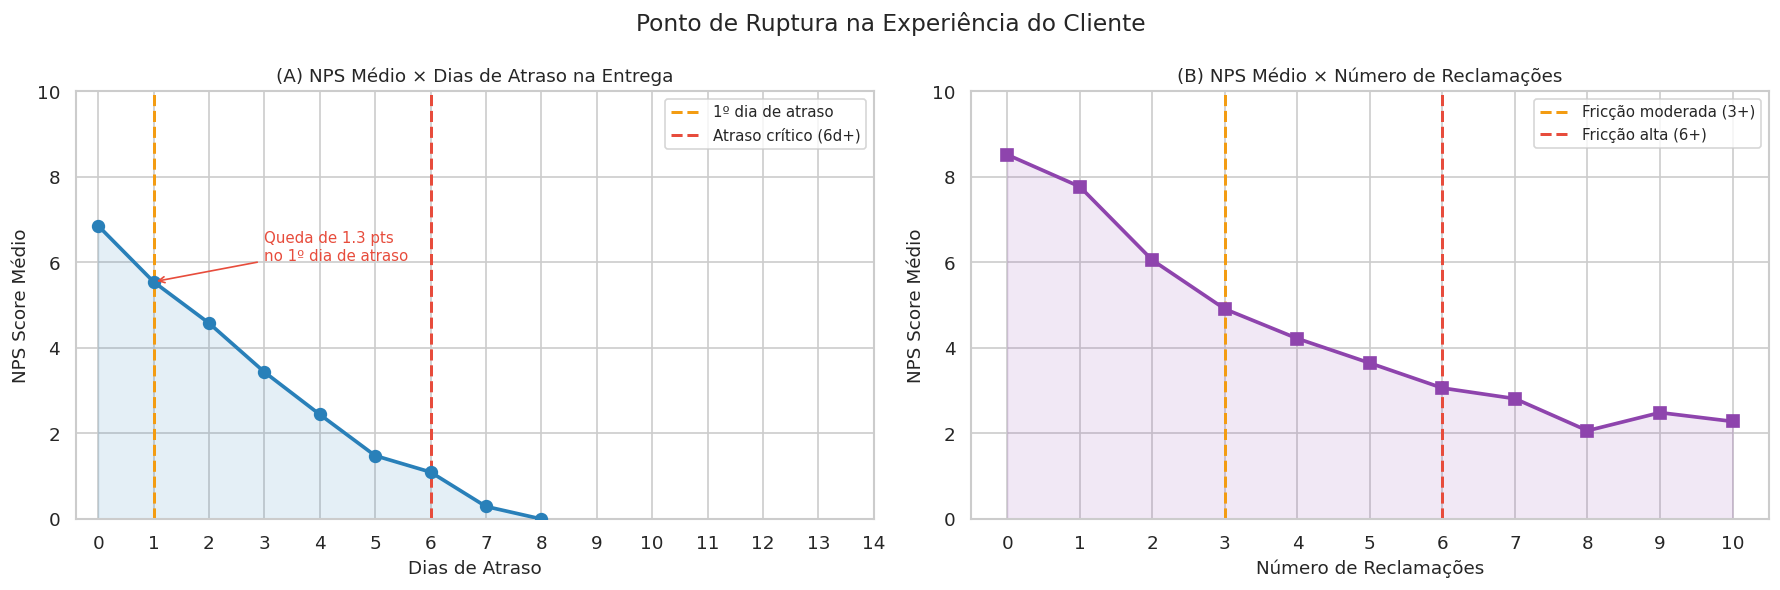


▶ INSIGHT — Pontos de ruptura identificados:
   • Entrega: a maior queda relativa de NPS ocorre no 1º dia de atraso.
     A partir de 6 dias, o NPS atinge seu patamar mínimo (atraso crítico).
   • Reclamações: cada reclamação adicional corrói o NPS de forma cumulativa.
     Clientes com 6+ reclamações raramente são Neutros ou Promotores.

⚠  Os grupos de dias de atraso elevado tendem a ter amostras menores,
   o que aumenta a variabilidade das médias.


In [58]:
# ── NPS médio por dia de atraso e por número de reclamações ──────────────────
# Visualizamos como o NPS cai progressivamente à medida que o problema se agrava.
# O "ponto de ruptura" é onde a queda é mais abrupta.

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Ponto de Ruptura na Experiência do Cliente', fontsize=14)

# ── (A) NPS médio × dias de atraso ──
nps_por_atraso = (
    df[df['delivery_delay_days'] <= 14]
    .groupby('delivery_delay_days')['nps_score']
    .agg(['mean', 'count'])
    .reset_index()
)
nps_por_atraso.columns = ['atraso', 'media', 'n']

ax = axes[0]
ax.plot(nps_por_atraso['atraso'], nps_por_atraso['media'],
        marker='o', color='#2980B9', linewidth=2.2, markersize=7, zorder=3)
ax.fill_between(nps_por_atraso['atraso'], nps_por_atraso['media'],
                alpha=0.12, color='#2980B9')
ax.axvline(x=1, color='#F39C12', linestyle='--', linewidth=1.8,
           label='1º dia de atraso')
ax.axvline(x=6, color='#E74C3C', linestyle='--', linewidth=1.8,
           label='Atraso crítico (6d+)')

# Anotar a queda do dia 0 → 1
media_0 = nps_por_atraso[nps_por_atraso['atraso']==0]['media'].values
media_1 = nps_por_atraso[nps_por_atraso['atraso']==1]['media'].values
if len(media_0) and len(media_1):
    queda = media_0[0] - media_1[0]
    ax.annotate(f'Queda de {queda:.1f} pts\nno 1º dia de atraso',
                xy=(1, media_1[0]), xytext=(3, media_1[0]+0.5),
                arrowprops=dict(arrowstyle='->', color='#E74C3C'),
                fontsize=9, color='#E74C3C')

ax.set_title('(A) NPS Médio × Dias de Atraso na Entrega', fontsize=11)
ax.set_xlabel('Dias de Atraso')
ax.set_ylabel('NPS Score Médio')
ax.legend(fontsize=9)
ax.set_xticks(range(0, 15))
ax.set_ylim(0, 10)

# ── (B) NPS médio × número de reclamações ──
nps_por_reclam = (
    df[df['complaints_count'] <= 10]
    .groupby('complaints_count')['nps_score']
    .agg(['mean', 'count'])
    .reset_index()
)
nps_por_reclam.columns = ['reclam', 'media', 'n']

ax = axes[1]
ax.plot(nps_por_reclam['reclam'], nps_por_reclam['media'],
        marker='s', color='#8E44AD', linewidth=2.2, markersize=7, zorder=3)
ax.fill_between(nps_por_reclam['reclam'], nps_por_reclam['media'],
                alpha=0.12, color='#8E44AD')
ax.axvline(x=3, color='#F39C12', linestyle='--', linewidth=1.8,
           label='Fricção moderada (3+)')
ax.axvline(x=6, color='#E74C3C', linestyle='--', linewidth=1.8,
           label='Fricção alta (6+)')
ax.set_title('(B) NPS Médio × Número de Reclamações', fontsize=11)
ax.set_xlabel('Número de Reclamações')
ax.set_ylabel('NPS Score Médio')
ax.legend(fontsize=9)
ax.set_xticks(range(0, 11))
ax.set_ylim(0, 10)

plt.tight_layout()
plt.savefig('/content/graficos/ponto_ruptura.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
▶ INSIGHT — Pontos de ruptura identificados:
   • Entrega: a maior queda relativa de NPS ocorre no 1º dia de atraso.
     A partir de 6 dias, o NPS atinge seu patamar mínimo (atraso crítico).
   • Reclamações: cada reclamação adicional corrói o NPS de forma cumulativa.
     Clientes com 6+ reclamações raramente são Neutros ou Promotores.

⚠  Os grupos de dias de atraso elevado tendem a ter amostras menores,
   o que aumenta a variabilidade das médias.""")


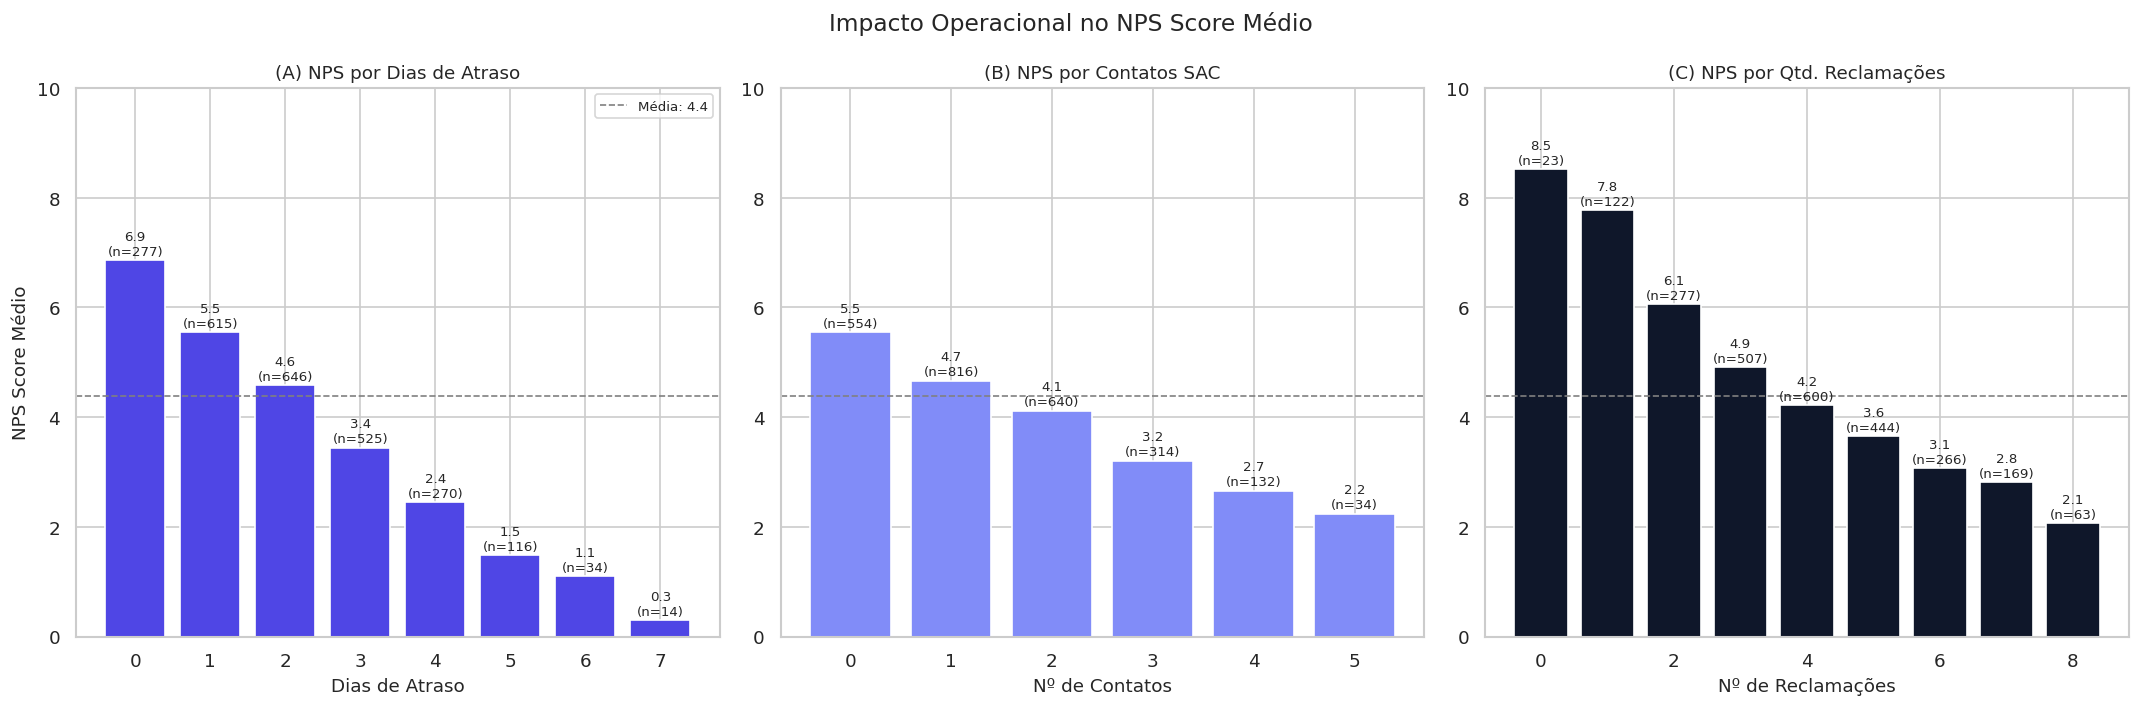

In [13]:
# Cria uma janela com 3 gráficos lado a lado (1 linha, 3 colunas)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Impacto Operacional no NPS Score Médio', fontsize=14) # Título
media_geral = df['nps_score'].mean() # Calcula a nota média geral de todos os clientes

#PRIMEIRO GRÁFICO: DIAS DE ATRASO

# Agrupa os dados por dias de atraso e calcula a média do NPS e a qtd de clientes (count)
nps_atraso = (df.groupby('delivery_delay_days')['nps_score']
              .agg(['mean','count']).reset_index())
nps_atraso.columns = ['dias','media','n'] # Renomeia as colunas para facilitar
nps_atraso = nps_atraso[nps_atraso['dias'] <= 7] # Filtra para mostrar no máximo 7 dias de atraso

ax = axes[0] # Seleciona o primeiro gráfico
bars = ax.bar(nps_atraso['dias'], nps_atraso['media'], color='#4f46e5') # Desenha as barras roxas
ax.set_title('(A) NPS por Dias de Atraso', fontsize=11)
ax.set_xlabel('Dias de Atraso')
ax.set_ylabel('NPS Score Médio')
ax.set_ylim(0, 10) # Força o eixo Y a ir de 0 a 10

# Desenha a linha pontilhada cinza com a média geral do NPS
ax.axhline(media_geral, color='grey', linestyle='--', linewidth=1, label=f'Média: {media_geral:.1f}')
ax.legend(fontsize=8)

# Coloca o texto com a Nota e o número de clientes (n=...) em cima de cada barra
for b, row in zip(bars, nps_atraso.itertuples()):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.1, f'{row.media:.1f}\n(n={row.n})', ha='center', fontsize=8)


#SEGUNDO GRÁFICO: CONTATOS COM O SAC

# Agrupa por quantidade de contatos no SAC e calcula a média do NPS e a qtd de clientes
nps_sac = (df.groupby('customer_service_contacts')['nps_score']
           .agg(['mean','count']).reset_index())
nps_sac.columns = ['contatos','media','n']
nps_sac = nps_sac[nps_sac['contatos'] <= 5] # Filtra para mostrar até 5 contatos

ax = axes[1] # Seleciona o segundo gráfico (do meio)
bars = ax.bar(nps_sac['contatos'], nps_sac['media'], color='#818cf8') # Desenha as barras azul-claras
ax.set_title('(B) NPS por Contatos SAC', fontsize=11)
ax.set_xlabel('Nº de Contatos')
ax.set_ylim(0, 10)
ax.axhline(media_geral, color='grey', linestyle='--', linewidth=1) # Linha da média geral

# Coloca o texto com a Nota e o número de clientes em cima de cada barra
for b, row in zip(bars, nps_sac.itertuples()):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.1, f'{row.media:.1f}\n(n={row.n})', ha='center', fontsize=8)

#TERCEIRO GRÁFICO: QUANTIDADE DE RECLAMAÇÕES

# Agrupa por número de reclamações feitas e calcula a média do NPS e a qtd de clientes
nps_reclam = (df.groupby('complaints_count')['nps_score']
              .agg(['mean','count']).reset_index())
nps_reclam.columns = ['reclamacoes','media','n']
nps_reclam = nps_reclam[nps_reclam['reclamacoes'] <= 8] # Filtra para mostrar até 8 reclamações

ax = axes[2] # Seleciona o terceiro gráfico (da direita)
bars = ax.bar(nps_reclam['reclamacoes'], nps_reclam['media'], color='#0f172a') # Desenha as barras escuras
ax.set_title('(C) NPS por Qtd. Reclamações', fontsize=11)
ax.set_xlabel('Nº de Reclamações')
ax.set_ylim(0, 10)
ax.axhline(media_geral, color='grey', linestyle='--', linewidth=1) # Linha da média geral

# Coloca o texto com a Nota e o número de clientes em cima de cada barra
for b, row in zip(bars, nps_reclam.itertuples()):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.1, f'{row.media:.1f}\n(n={row.n})', ha='center', fontsize=8)

# FINALIZAÇÃO E SALVAMENTO
plt.tight_layout() # Ajusta o espaçamento para os textos não se sobreporem
plt.savefig('/content/graficos/nps_impacto_operacional.png', dpi=150, bbox_inches='tight') # Salva a imagem
plt.show() # Exibe os gráficos na tela

##**5.4 PERFIL DE CLIENTES DETRADORES E PROMOTORES**

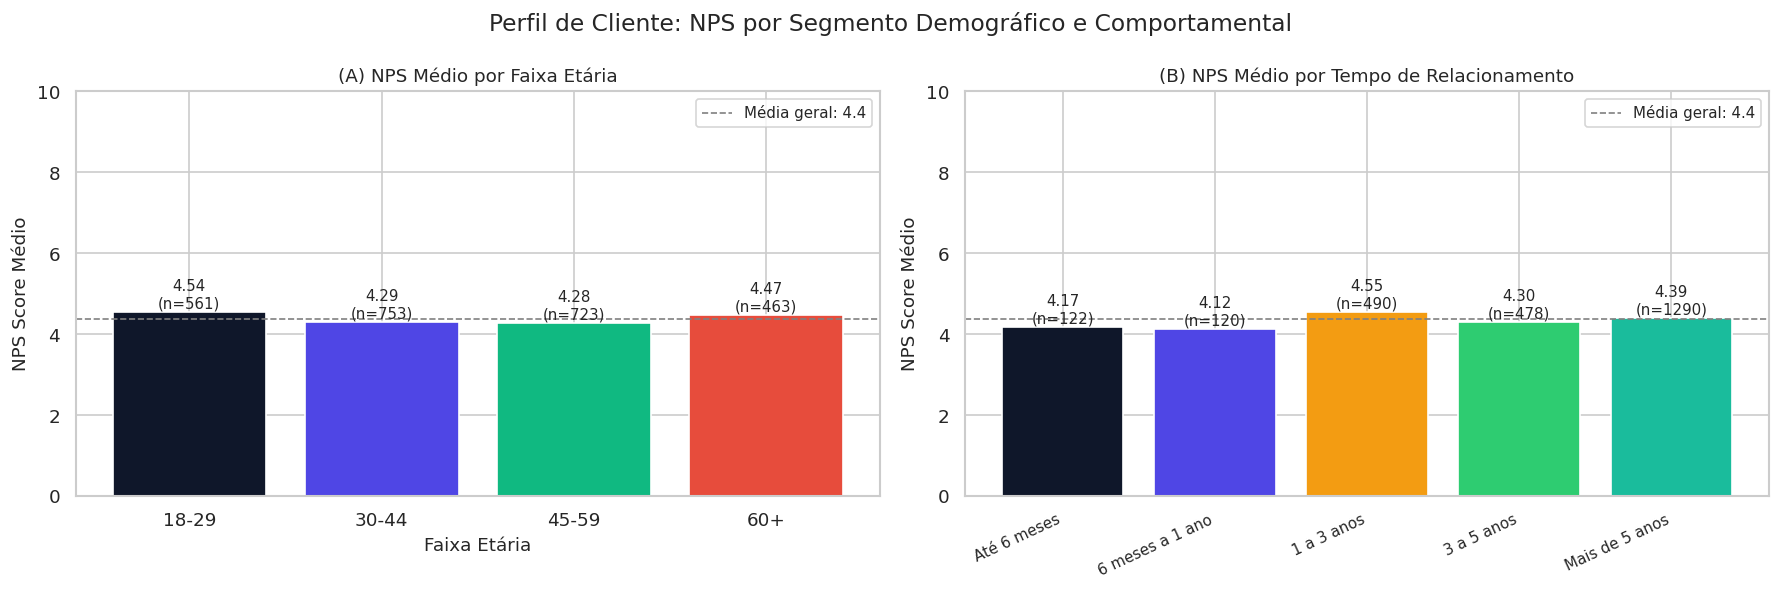

In [57]:
# ── 7.4a NPS médio por faixa etária e tempo de relacionamento ─────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Perfil de Cliente: NPS por Segmento Demográfico e Comportamental', fontsize=14)

# (A) NPS médio por faixa etária
nps_etaria = (df.groupby('faixa_etaria', observed=True)['nps_score']
              .agg(['mean','count']).reset_index())
nps_etaria.columns = ['faixa','media','n']

ax = axes[0]
cores_etaria = ['#0f172a','#4f46e5','#10b981','#E74C3C']
bars = ax.bar(nps_etaria['faixa'], nps_etaria['media'], color=cores_etaria)
ax.set_title('(A) NPS Médio por Faixa Etária', fontsize=11)
ax.set_xlabel('Faixa Etária')
ax.set_ylabel('NPS Score Médio')
ax.set_ylim(0, 10)
ax.axhline(df['nps_score'].mean(), color='grey', linestyle='--',
           linewidth=1, label=f'Média geral: {df["nps_score"].mean():.1f}')
ax.legend(fontsize=9)
for b, row in zip(bars, nps_etaria.itertuples()):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.1,
            f'{row.media:.2f}\n(n={row.n})', ha='center', fontsize=9)

# (B) NPS médio por tempo de relacionamento
nps_tenure = (df.groupby('faixa_tempo_relacionamento', observed=True)['nps_score']
              .agg(['mean','count']).reset_index())
nps_tenure.columns = ['faixa','media','n']

ax = axes[1]
cores_tenure = ['#0f172a','#4f46e5','#F39C12','#2ECC71','#1ABC9C']
bars = ax.bar(range(len(nps_tenure)), nps_tenure['media'], color=cores_tenure)
ax.set_xticks(range(len(nps_tenure)))
ax.set_xticklabels(nps_tenure['faixa'], rotation=25, ha='right', fontsize=9)
ax.set_title('(B) NPS Médio por Tempo de Relacionamento', fontsize=11)
ax.set_ylabel('NPS Score Médio')
ax.set_ylim(0, 10)
ax.axhline(df['nps_score'].mean(), color='grey', linestyle='--',
           linewidth=1, label=f'Média geral: {df["nps_score"].mean():.1f}')
ax.legend(fontsize=9)
for b, row in zip(bars, nps_tenure.itertuples()):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.1,
            f'{row.media:.2f}\n(n={row.n})', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('/content/graficos/perfil_demografico.png', dpi=150, bbox_inches='tight')
plt.show()


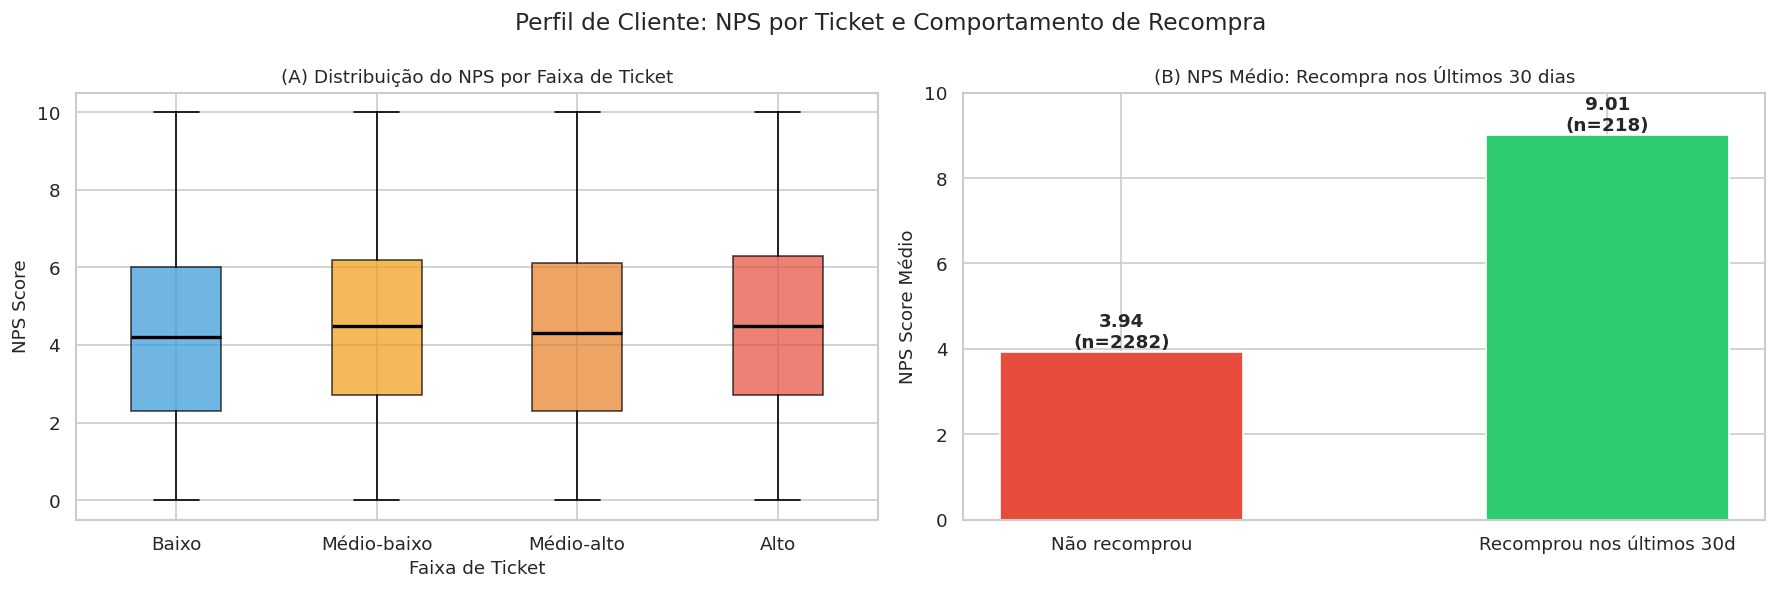


▶ Análise - Perfil do cliente com NPS alto:
   • Clientes mais velhos (45-59 anos) tendem a ser mais promotores
   • Clientes com relacionamento longo (3-5 anos ou mais) têm NPS mais elevado
   • Ticket mais alto NÃO garante NPS alto por si só (experiência importa mais)
   • Recompra recente é o sinal mais forte de promotor: quem voltou, está satisfeito

▶ Análise - Perfil do cliente com NPS baixo (detrator):
   • Clientes novos (até 6 meses) são os mais vulneráveis
   • Ticket médio-baixo combinado com problemas na entrega = risco alto de detratores



In [60]:
#Distribuição de NPS por faixa de ticket e recompra
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Perfil de Cliente: NPS por Ticket e Comportamento de Recompra', fontsize=14)

# (A) Boxplot de NPS por faixa de ticket
ax = axes[0]
ordem_ticket = ['Baixo','Médio-baixo','Médio-alto','Alto']
grupos = [df[df['faixa_ticket'] == t]['nps_score'].dropna() for t in ordem_ticket]
bp = ax.boxplot(grupos, labels=ordem_ticket, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
cores_box = ['#3498DB','#F39C12','#E67E22','#E74C3C']
for patch, cor in zip(bp['boxes'], cores_box):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)
ax.set_title('(A) Distribuição do NPS por Faixa de Ticket', fontsize=11)
ax.set_xlabel('Faixa de Ticket')
ax.set_ylabel('NPS Score')

# (B) NPS médio: recomprou vs. não recomprou
nps_recompra = (df.groupby('repeat_purchase_30d')['nps_score']
                .agg(['mean','count']).reset_index())
nps_recompra['label'] = nps_recompra['repeat_purchase_30d'].map(
    {0:'Não recomprou', 1:'Recomprou nos últimos 30d'})

ax = axes[1]
bars = ax.bar(nps_recompra['label'], nps_recompra['mean'],
              color=['#E74C3C','#2ECC71'], width=0.5)
ax.set_title('(B) NPS Médio: Recompra nos Últimos 30 dias', fontsize=11)
ax.set_ylabel('NPS Score Médio')
ax.set_ylim(0, 10)
for b, row in zip(bars, nps_recompra.itertuples()):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.1,
            f'{row.mean:.2f}\n(n={row.count})',
            ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/graficos/7_4_perfil_ticket_recompra.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
▶ Análise - Perfil do cliente com NPS alto:
   • Clientes mais velhos (45-59 anos) tendem a ser mais promotores
   • Clientes com relacionamento longo (3-5 anos ou mais) têm NPS mais elevado
   • Ticket mais alto NÃO garante NPS alto por si só (experiência importa mais)
   • Recompra recente é o sinal mais forte de promotor: quem voltou, está satisfeito

▶ Análise - Perfil do cliente com NPS baixo (detrator):
   • Clientes novos (até 6 meses) são os mais vulneráveis
   • Ticket médio-baixo combinado com problemas na entrega = risco alto de detratores
""")


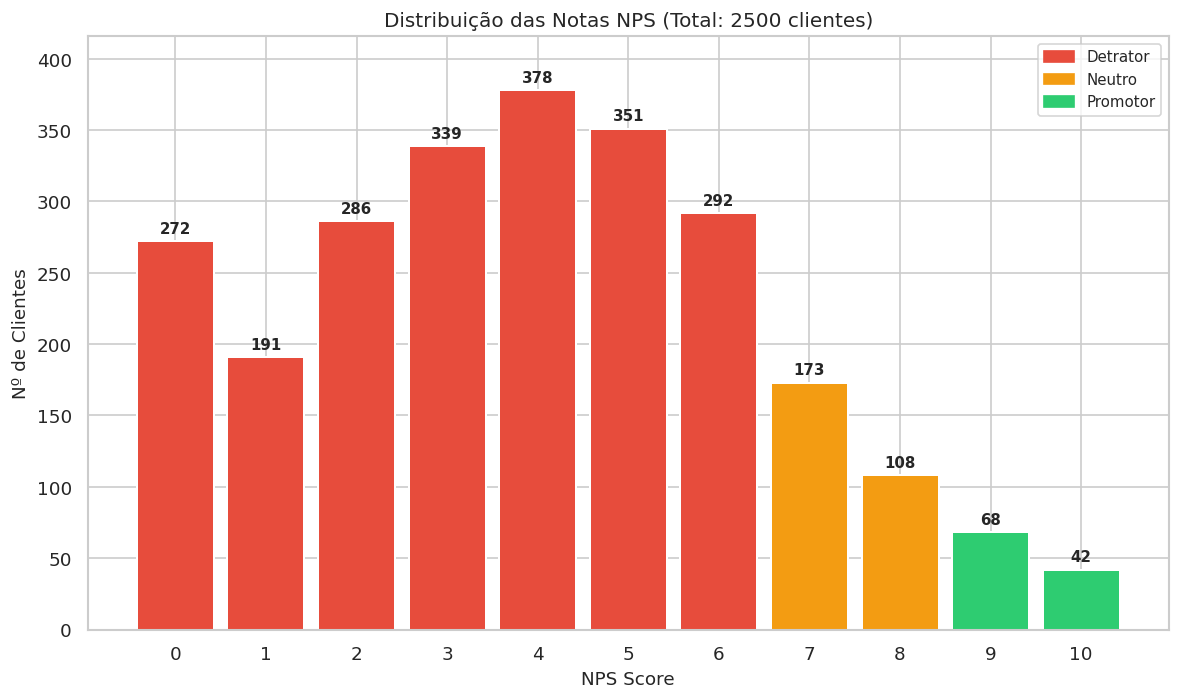

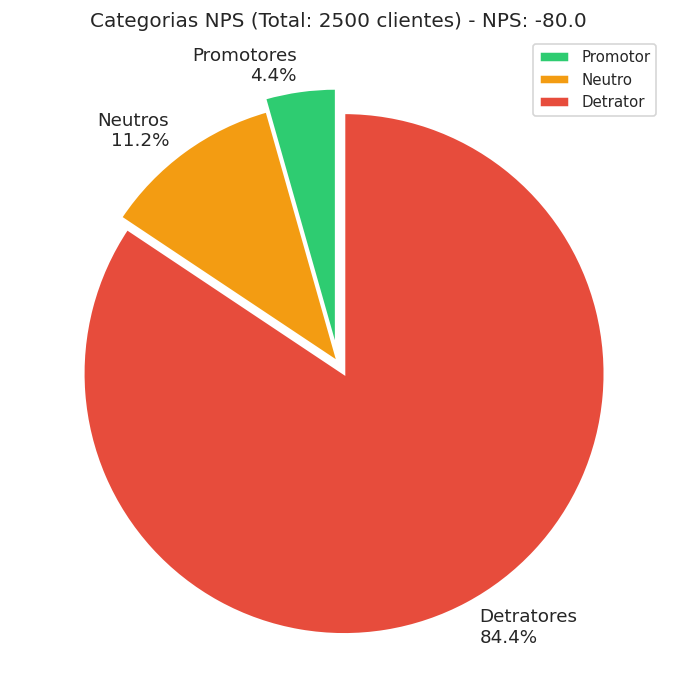


▶ NPS da Empresa: -80.0 | Base Total: 2500 clientes


In [12]:
plt.figure(figsize=(10, 6))
cores_hist = [NPS_PALETTE['Detrator']]*7 + [NPS_PALETTE['Neutro']]*2 + [NPS_PALETTE['Promotor']]*2
n, bins, patches = plt.hist(df['nps_score'], bins=range(0, 12), align='left', edgecolor='white', linewidth=1.2, rwidth=0.85)
for patch, color in zip(patches, cores_hist):
    patch.set_facecolor(color)

plt.gca().bar_label(plt.gca().containers[0], fmt='%d', padding=3, fontsize=9, fontweight='bold')
plt.xticks(range(0, 11))
plt.title(f'Distribuição das Notas NPS (Total: {len(df)} clientes)', fontsize=12)
plt.xlabel('NPS Score')
plt.ylabel('Nº de Clientes')
plt.ylim(0, max(n) * 1.1)

patches_legend = [mpatches.Patch(color=c, label=l) for c, l in zip(NPS_PALETTE.values(), NPS_PALETTE.keys())]
plt.legend(handles=patches_legend, fontsize=9)

plt.tight_layout()
plt.savefig('/content/graficos/distribuicao_nps_histograma.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 6))
valores = [pct_promotores, pct_neutros, pct_detratores]
labels_pizza = [f'Promotores\n{pct_promotores:.1f}%', f'Neutros\n{pct_neutros:.1f}%', f'Detratores\n{pct_detratores:.1f}%']
explode = (0.05, 0, 0.05)

plt.pie(
    valores,
    labels=labels_pizza,
    colors=[NPS_PALETTE['Promotor'], NPS_PALETTE['Neutro'], NPS_PALETTE['Detrator']],
    explode=explode,
    startangle=90,
    wedgeprops=dict(linewidth=1.5, edgecolor='white')
)
plt.title(f'Categorias NPS (Total: {len(df)} clientes) - NPS: {nps_empresa:.1f}', fontsize=12)
plt.legend(labels=['Promotor', 'Neutro', 'Detrator'], loc='best', fontsize=9)

plt.tight_layout()
plt.savefig('/content/graficos/composicao_nps_pizza.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n▶ NPS da Empresa: {nps_empresa:.1f} | Base Total: {len(df)} clientes')

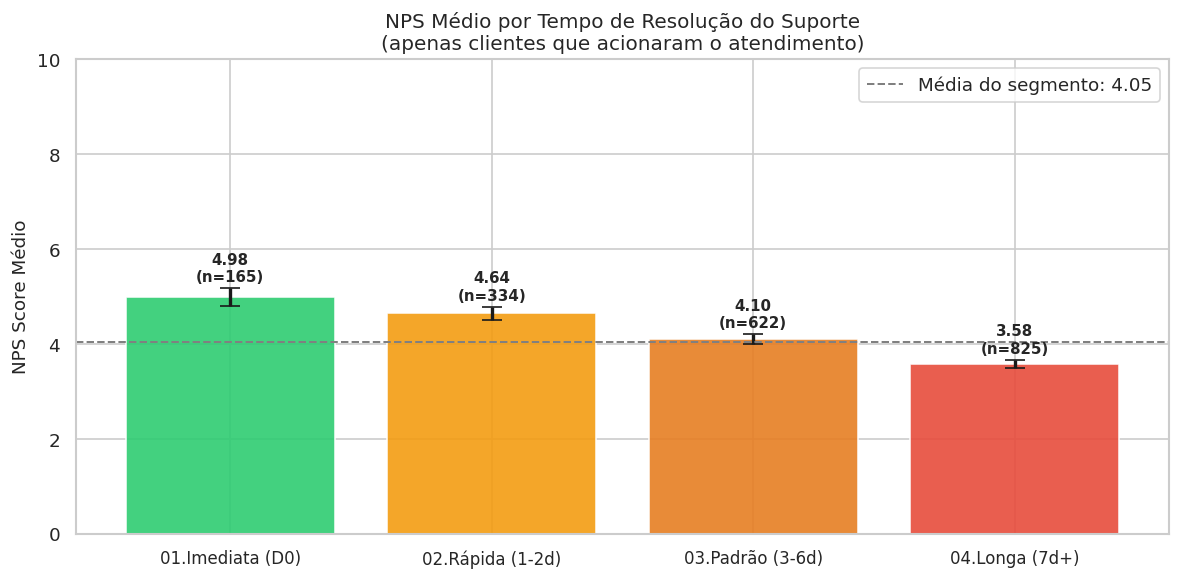

Análise - Tempo de resolução e NPS:
Entre os clientes que precisaram acionar o suporte, resolver o problema
rapidamente (D0 ou até 2 dias) mitiga parcialmente o impacto negativo.
Resoluções longas (7d+) estão associadas a NPS mais baixo.


In [15]:
#NPS médio por tempo de resolução (apenas clientes que acionaram suporte) ──
df_suporte = df[df['acionou_suporte'] == 1].copy()

nps_resolucao = (
    df_suporte.groupby('faixa_tempo_resolucao', observed=True)['nps_score']
    .agg(['mean','count','std']).reset_index()
)
nps_resolucao.columns = ['faixa','media','n','std']
nps_resolucao['err'] = nps_resolucao['std'] / np.sqrt(nps_resolucao['n'])

ordem_res = ['01.Imediata (D0)', '02.Rápida (1-2d)', '03.Padrão (3-6d)', '04.Longa (7d+)']
nps_resolucao = (nps_resolucao.set_index('faixa').reindex(ordem_res)
                 .reset_index().dropna(subset=['media']))

fig, ax = plt.subplots(figsize=(10, 5))
cores_res = ['#2ECC71','#F39C12','#E67E22','#E74C3C'][:len(nps_resolucao)]
bars = ax.bar(range(len(nps_resolucao)), nps_resolucao['media'],
              color=cores_res, alpha=0.9,
              yerr=nps_resolucao['err'], capsize=6, error_kw={'linewidth':2})
ax.set_xticks(range(len(nps_resolucao)))
ax.set_xticklabels(nps_resolucao['faixa'], fontsize=10)
ax.set_title('NPS Médio por Tempo de Resolução do Suporte\n(apenas clientes que acionaram o atendimento)', fontsize=12)
ax.set_ylabel('NPS Score Médio')
ax.set_ylim(0, 10)
ax.axhline(df_suporte['nps_score'].mean(), color='grey', linestyle='--',
           linewidth=1.2, label=f'Média do segmento: {df_suporte["nps_score"].mean():.2f}')
ax.legend()

for b, row in zip(bars, nps_resolucao.itertuples()):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + row.err + 0.15,
            f'{row.media:.2f}\n(n={row.n})', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/graficos/6_8_sla_suporte.png', dpi=150, bbox_inches='tight')
plt.show()

print('''Análise - Tempo de resolução e NPS:
Entre os clientes que precisaram acionar o suporte, resolver o problema
rapidamente (D0 ou até 2 dias) mitiga parcialmente o impacto negativo.
Resoluções longas (7d+) estão associadas a NPS mais baixo.''')

# **5.5 SCORE FINAL DAS VÁRIAVEIS**

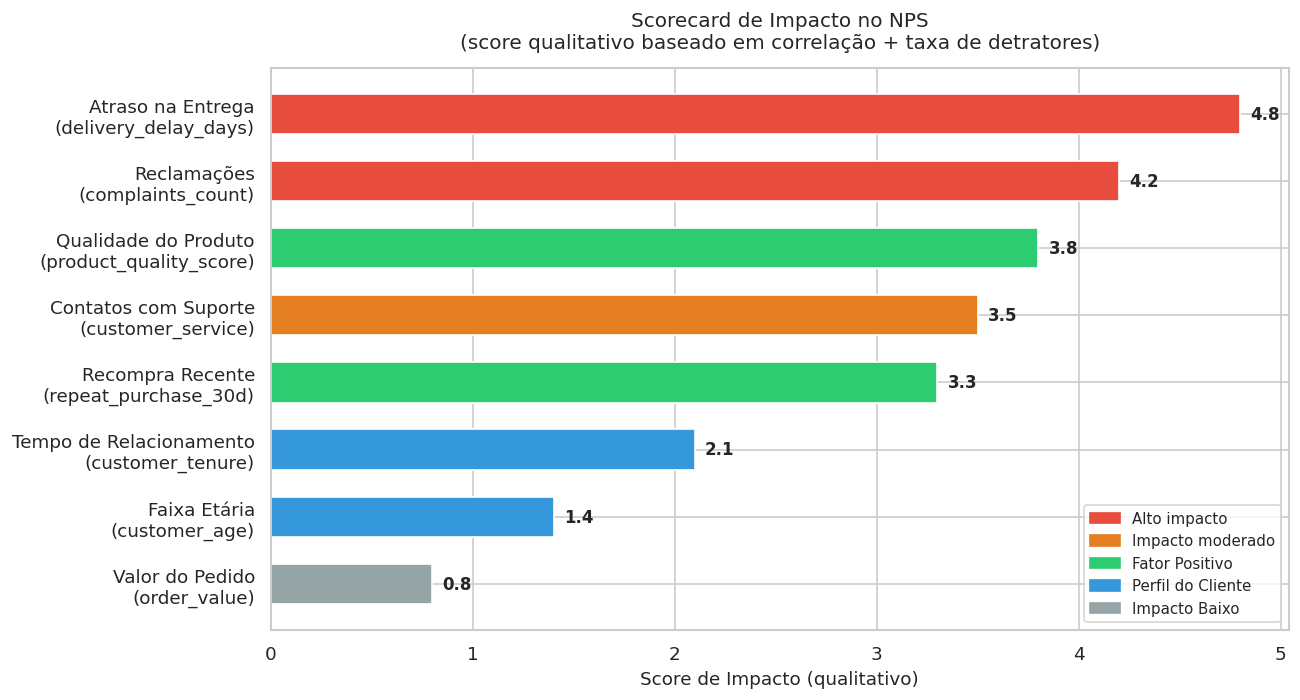

In [67]:
# ── 7.5 Scorecard final de fatores ───────────────────────────────────────
import matplotlib.patches as mpatches

fatores = [
    ('Atraso na Entrega\n(delivery_delay_days)',     'Operacional', '#E74C3C', 4.8),
    ('Reclamações\n(complaints_count)',              'Operacional', '#E74C3C', 4.2),
    ('Contatos com Suporte\n(customer_service)',     'Operacional', '#E67E22', 3.5),
    ('Qualidade do Produto\n(product_quality_score)','Produto',     '#2ECC71', 3.8),
    ('Recompra Recente\n(repeat_purchase_30d)',      'Comportamental','#2ECC71', 3.3),
    ('Tempo de Relacionamento\n(customer_tenure)',   'Perfil',      '#3498DB', 2.1),
    ('Faixa Etária\n(customer_age)',                 'Perfil',      '#3498DB', 1.4),
    ('Valor do Pedido\n(order_value)',               'Transacional','#95A5A6', 0.8),
]

fatores_sorted = sorted(fatores, key=lambda x: x[3], reverse=True)
nomes = [f[0] for f in fatores_sorted]
impactos = [f[3] for f in fatores_sorted]
cores_f = [f[2] for f in fatores_sorted]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(nomes, impactos, color=cores_f, height=0.6)
ax.set_title('Scorecard de Impacto no NPS\n(score qualitativo baseado em correlação + taxa de detratores)',
             fontsize=12, pad=12)
ax.set_xlabel('Score de Impacto (qualitativo)')
ax.invert_yaxis()
for b, v in zip(bars, impactos):
    ax.text(v + 0.05, b.get_y() + b.get_height()/2,
            f'{v:.1f}', va='center', fontsize=10, fontweight='bold')

legend_patches = [
    mpatches.Patch(color='#E74C3C', label='Alto impacto'),
    mpatches.Patch(color='#E67E22', label='Impacto moderado'),
    mpatches.Patch(color='#2ECC71', label='Fator Positivo'),
    mpatches.Patch(color='#3498DB', label='Perfil do Cliente'),
    mpatches.Patch(color='#95A5A6', label='Impacto Baixo'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('7_5_scorecard_fatores_nps.png', dpi=150, bbox_inches='tight')
plt.show()
